# Validating Eq. 8, Eq. 14 and Eq. 18 independently

NOT EXECUTED on my side, at your request. Syntax-checked only.

| eq | what it says | tested how |
|----|--------------|------------|
| **8**  | `p_c = min(theta, 2*arcsin(r/VR)) / (2*pi)` | **direct microscopic MC** — one isolated target, one step. Does NOT use the MFPT, `A`, `b`, or any fitted constant. This is the cleanest of the three. |
| **14** | `T_vis = (VR^2-tau^2) + A*ln(tau/VR_eff) + eps*VR` | three separate sub-tests, because a single pass/fail would conflate the *structure* with the *fitted constants* |
| **18** | `T_blind = T_inf*(1 - B*(r/tau)^psi)` | tau-scan + fit; checks `T_inf` against the analytic MFP and discriminates `psi=1` vs `psi=2` |

**Read the caveat in section 5 before trusting any of it.** The dominant error
here is almost certainly NOT the walker count.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
from tqdm.auto import tqdm

# ============ YOUR PARAMETERS ============
L, Nt, r = 300, 90, 0.5
TAU = 8.0
THETA = 2 * np.pi
# =========================================

D_STEP = 1.0                      # physical step -> D = d/4 = 1/4
rho = Nt / L**2
A = 2 / (np.pi * rho)
B_CELL = 1 / np.sqrt(np.pi * rho)
MFP = 1 / (2 * r * rho)

# fitted constants under test
ELL_A, ELL_C = 1.79, 0.45
CONE_A, CONE_C = 1.97, 0.56
EPS = 0.8                         # run-in cost ~ EPS*VR
KAPPA = 0.52                      # contact floor = KAPPA*r  (when d > r)
B_OPT, B_PURE, PSI = 0.73, 0.38, 1.0

print(f"rho={rho:.4g}  A={A:.1f}  b={B_CELL:.2f}  MFP={MFP:.1f}  tau={TAU}")
print(f"windows: model needs 3d={3*D_STEP} <= VR < tau <= 0.6b={0.6*B_CELL:.1f}; "
      f"sim needs tau < L/3={L/3:.1f}")

rho=0.001  A=636.6  b=17.84  MFP=1000.0  tau=8.0
windows: model needs 3d=3.0 <= VR < tau <= 0.6b=10.7; sim needs tau < L/3=100.0


## Simulators (self-contained)

In [ ]:
def _minimg(delta, L):
    return delta - L * np.round(delta / L)


def run_visual(L, Nt, r, VR, tau, theta, W, seed, rule='dir', max_steps=200000):
    """Diffusive visual searcher. Vision (cone+dash) OR contact. Returns (path, done)."""
    rng = np.random.default_rng(seed)
    targets = rng.uniform(0, L, size=(Nt, 2))
    tree = cKDTree(targets, boxsize=L)
    ti = rng.integers(0, Nt, size=W)
    a0 = rng.uniform(0, 2 * np.pi, size=W)
    pos = (targets[ti] + tau * np.column_stack([np.cos(a0), np.sin(a0)])) % L
    path = np.zeros(W); done = np.zeros(W, bool); idx = np.arange(W)
    half = theta / 2.0
    Rsearch = max(VR, D_STEP + r) + 1e-9
    for _ in range(max_steps):
        act = ~done
        if not act.any():
            break
        p = pos[act]; ai = idx[act]
        if rule == 'iso':
            dist, _ = tree.query(p, k=1)
            hit = dist <= VR
            if hit.any():
                path[ai[hit]] += dist[hit]; done[ai[hit]] = True
            mv = ~hit
            if mv.any():
                ang = rng.uniform(0, 2 * np.pi, size=int(mv.sum()))
                pos[ai[mv]] = (p[mv] + np.column_stack([np.cos(ang), np.sin(ang)])) % L
                path[ai[mv]] += D_STEP
            continue
        ang = rng.uniform(0, 2 * np.pi, size=len(p))
        h = np.column_stack([np.cos(ang), np.sin(ang)])
        capt = np.zeros(len(p), bool); cost = np.zeros(len(p))
        neigh = tree.query_ball_point(p, Rsearch)
        for k in range(len(p)):
            lst = neigh[k]
            if not lst:
                continue
            dvec = _minimg(targets[lst] - p[k], L)
            dd = np.hypot(dvec[:, 0], dvec[:, 1])
            s = dvec[:, 0] * h[k, 0] + dvec[:, 1] * h[k, 1]
            cross = h[k, 0] * dvec[:, 1] - h[k, 1] * dvec[:, 0]
            perp = np.abs(cross)
            ray_hits = (perp <= r) & (s > 0)
            if not ray_hits.any():
                continue
            entry = np.where(ray_hits, s - np.sqrt(np.clip(r**2 - perp**2, 0, None)), np.inf)
            entry = np.clip(entry, 0.0, None)
            bear = np.abs(np.arctan2(cross, s))
            vision = ray_hits & (dd <= VR) & (bear <= half)
            contact = ray_hits & (entry <= D_STEP)
            ok = vision | contact
            if ok.any():
                capt[k] = True; cost[k] = entry[ok].min()
        if capt.any():
            path[ai[capt]] += cost[capt]; done[ai[capt]] = True
        mv = ~capt
        if mv.any():
            pos[ai[mv]] = (p[mv] + h[mv]) % L; path[ai[mv]] += D_STEP
    return path, done


def mfpt_visual(**kw):
    path, done = run_visual(**kw)
    p = path[done]
    return p.mean(), p.std() / np.sqrt(max(len(p), 1)), 1 - done.mean()



In [ ]:
import numba


@numba.njit(cache=True)
def run_visual_numba(L, Nt, r, VR, tau, theta, W, seed, rule_iso=False, max_steps=200000):
    """Numba JIT version of run_visual — brute-force periodic NN replaces cKDTree.

    rule_iso : bool — True for rule='iso', False for rule='dir' (default).
    Returns (path, done) arrays, identical interface to run_visual.
    """
    np.random.seed(seed)
    D_STEP = 1.0

    # --- targets ---
    targets = np.empty((Nt, 2))
    for i in range(Nt):
        targets[i, 0] = np.random.uniform(0.0, L)
        targets[i, 1] = np.random.uniform(0.0, L)

    # --- initial positions: random target + tau-offset ---
    pos = np.empty((W, 2))
    for i in range(W):
        ti = np.random.randint(0, Nt)
        a0 = np.random.uniform(0.0, 2.0 * np.pi)
        pos[i, 0] = (targets[ti, 0] + tau * np.cos(a0)) % L
        pos[i, 1] = (targets[ti, 1] + tau * np.sin(a0)) % L

    path = np.zeros(W)
    done = np.zeros(W, dtype=np.bool_)

    half = theta / 2.0
    Rsearch = max(VR, D_STEP + r) + 1e-9
    Rsearch2 = Rsearch * Rsearch
    r2 = r * r

    for _ in range(max_steps):
        all_done = True
        for i in range(W):
            if not done[i]:
                all_done = False
                break
        if all_done:
            break

        for i in range(W):
            if done[i]:
                continue

            px, py = pos[i, 0], pos[i, 1]

            if rule_iso:
                # iso: find nearest target; if within VR, capture with path cost = dist
                best2 = np.inf
                for j in range(Nt):
                    dx = px - targets[j, 0]
                    dy = py - targets[j, 1]
                    dx -= L * np.round(dx / L)
                    dy -= L * np.round(dy / L)
                    d2 = dx * dx + dy * dy
                    if d2 < best2:
                        best2 = d2
                best_d = np.sqrt(best2)
                if best_d <= VR:
                    path[i] += best_d
                    done[i] = True
                else:
                    ang = np.random.uniform(0.0, 2.0 * np.pi)
                    pos[i, 0] = (px + np.cos(ang)) % L
                    pos[i, 1] = (py + np.sin(ang)) % L
                    path[i] += D_STEP

            else:
                # dir: random heading, vision cone (bear <= half, dd <= VR) + contact (entry <= d)
                ang = np.random.uniform(0.0, 2.0 * np.pi)
                hx = np.cos(ang)
                hy = np.sin(ang)

                capt = False
                min_entry = np.inf

                for j in range(Nt):
                    dx = targets[j, 0] - px
                    dy = targets[j, 1] - py
                    dx -= L * np.round(dx / L)
                    dy -= L * np.round(dy / L)
                    d2 = dx * dx + dy * dy
                    if d2 > Rsearch2:
                        continue

                    s = dx * hx + dy * hy          # along-ray projection
                    if s <= 0.0:
                        continue
                    cross = hx * dy - hy * dx      # perpendicular (signed)
                    perp = abs(cross)
                    if perp > r:
                        continue                    # ray misses disk

                    # ray hits disk: entry point along ray
                    entry = s - np.sqrt(max(r2 - perp * perp, 0.0))
                    if entry < 0.0:
                        entry = 0.0

                    dd = np.sqrt(d2)
                    bear = abs(np.arctan2(cross, s))

                    vision = (dd <= VR) and (bear <= half)
                    contact = entry <= D_STEP

                    if vision or contact:
                        capt = True
                        if entry < min_entry:
                            min_entry = entry

                if capt:
                    path[i] += min_entry
                    done[i] = True
                else:
                    pos[i, 0] = (px + hx) % L
                    pos[i, 1] = (py + hy) % L
                    path[i] += D_STEP

    return path, done


def mfpt_visual_numba(L, Nt, r, VR, tau, theta, W, seed, rule='dir', max_steps=200000):
    """Python wrapper: Numba-accelerated mfpt_visual. Identical interface to mfpt_visual."""
    path, done = run_visual_numba(L, Nt, r, VR, tau, theta, W, seed,
                                   rule_iso=(rule == 'iso'), max_steps=max_steps)
    p = path[done]
    return p.mean(), p.std() / np.sqrt(max(len(p), 1)), 1.0 - done.mean()


In [ ]:

def run_flight(L, Nt, r, tau, dscales, weights, W, seed, h=0.2, max_path=40000):
    """Blind ballistic biexponential searcher. h is NUMERICAL (0.2 converged)."""
    rng = np.random.default_rng(seed)
    targets = rng.uniform(0, L, size=(Nt, 2))
    tree = cKDTree(targets, boxsize=L)
    ti = rng.integers(0, Nt, size=W)
    a0 = rng.uniform(0, 2 * np.pi, size=W)
    pos = (targets[ti] + tau * np.column_stack([np.cos(a0), np.sin(a0)])) % L
    head = np.zeros((W, 2)); remaining = np.zeros(W)
    path = np.zeros(W); done = np.zeros(W, bool)
    dscales = np.asarray(dscales, float)
    cw = np.cumsum(np.asarray(weights, float)); cw /= cw[-1]

    def new_flights(mask):
        n = int(mask.sum())
        if n == 0:
            return
        mode = np.searchsorted(cw, rng.random(n))
        Ls = -dscales[mode] * np.log(rng.random(n))
        ang = rng.uniform(0, 2 * np.pi, n)
        head[mask] = np.column_stack([np.cos(ang), np.sin(ang)])
        remaining[mask] = Ls

    new_flights(~done)
    for _ in range(int(max_path / h)):
        act = ~done
        if not act.any():
            break
        new_flights(act & (remaining <= 0))
        pos[act] = (pos[act] + h * head[act]) % L
        remaining[act] -= h; path[act] += h
        d_near, _ = tree.query(pos[act], k=1)
        hit = d_near <= r
        if hit.any():
            done[np.where(act)[0][hit]] = True
    p = path[done]
    return p.mean(), p.std() / np.sqrt(max(len(p), 1)), 1 - done.mean()

In [ ]:
import numba


@numba.njit(cache=True)
def run_flight_numba(L, Nt, r, tau, dscales, weights, W, seed, h=0.2, max_path=40000.0):
    """Numba JIT version of run_flight — brute-force periodic NN replaces cKDTree.

    dscales, weights : 1-D float64 numpy arrays (same meaning as run_flight).
    Returns (mean_path, sem, censored_fraction) — identical interface.
    """
    np.random.seed(seed)

    # --- targets ---
    targets = np.empty((Nt, 2))
    for i in range(Nt):
        targets[i, 0] = np.random.uniform(0.0, L)
        targets[i, 1] = np.random.uniform(0.0, L)

    # --- normalised cumulative weights ---
    n_modes = len(dscales)
    cw = np.empty(n_modes)
    cw[0] = weights[0]
    for k in range(1, n_modes):
        cw[k] = cw[k - 1] + weights[k]
    total_w = cw[n_modes - 1]
    for k in range(n_modes):
        cw[k] /= total_w

    # --- initial positions (random target + tau-offset) ---
    pos = np.empty((W, 2))
    for i in range(W):
        ti = np.random.randint(0, Nt)
        a0 = np.random.uniform(0.0, 2.0 * np.pi)
        pos[i, 0] = (targets[ti, 0] + tau * np.cos(a0)) % L
        pos[i, 1] = (targets[ti, 1] + tau * np.sin(a0)) % L

    head = np.empty((W, 2))
    remaining = np.zeros(W)
    path = np.zeros(W)
    done = np.zeros(W, dtype=np.bool_)

    # --- assign first flight to every walker ---
    for i in range(W):
        u = np.random.random()
        mode = n_modes - 1
        for k in range(n_modes):
            if u <= cw[k]:
                mode = k
                break
        remaining[i] = -dscales[mode] * np.log(np.random.random() + 1e-300)
        ang = np.random.uniform(0.0, 2.0 * np.pi)
        head[i, 0] = np.cos(ang)
        head[i, 1] = np.sin(ang)

    r2 = r * r
    n_steps = int(max_path / h)

    for _ in range(n_steps):
        # early exit if all walkers finished
        all_done = True
        for i in range(W):
            if not done[i]:
                all_done = False
                break
        if all_done:
            break

        for i in range(W):
            if done[i]:
                continue

            # start a new flight segment when the current one is exhausted
            if remaining[i] <= 0.0:
                u = np.random.random()
                mode = n_modes - 1
                for k in range(n_modes):
                    if u <= cw[k]:
                        mode = k
                        break
                remaining[i] = -dscales[mode] * np.log(np.random.random() + 1e-300)
                ang = np.random.uniform(0.0, 2.0 * np.pi)
                head[i, 0] = np.cos(ang)
                head[i, 1] = np.sin(ang)

            # advect
            pos[i, 0] = (pos[i, 0] + h * head[i, 0]) % L
            pos[i, 1] = (pos[i, 1] + h * head[i, 1]) % L
            remaining[i] -= h
            path[i] += h

            # capture check: any target within r? (brute-force, min-image PBC)
            for j in range(Nt):
                dx = pos[i, 0] - targets[j, 0]
                dy = pos[i, 1] - targets[j, 1]
                dx -= L * np.round(dx / L)
                dy -= L * np.round(dy / L)
                if dx * dx + dy * dy <= r2:
                    done[i] = True
                    break

    # --- output statistics ---
    count = 0
    total = 0.0
    for i in range(W):
        if done[i]:
            count += 1
            total += path[i]
    if count == 0:
        return 0.0, 0.0, 1.0
    mean = total / count
    sq = 0.0
    for i in range(W):
        if done[i]:
            sq += (path[i] - mean) ** 2
    std = np.sqrt(sq / max(count - 1, 1))
    sem = std / np.sqrt(float(count))
    return mean, sem, 1.0 - float(count) / float(W)


## Theory under test

In [ ]:
def p_c_eq8(theta, r, VR):
    return min(theta, 2 * np.arcsin(min(r / VR, 1.0))) / (2 * np.pi)


def ell_eq11_12(VR, r, theta=2 * np.pi):
    e = ELL_A * np.log(VR / r) + ELL_C
    pcw, pcn = p_c_eq8(2 * np.pi, r, VR), p_c_eq8(theta, r, VR)
    if pcn < pcw:
        e += CONE_A * np.log(pcw / pcn) + CONE_C
    return max(e, 0.0)


def VR_eff_eq13(VR, r, theta=2 * np.pi, d=D_STEP):
    floor = KAPPA * r if d > r else r
    return max(VR * np.exp(-ell_eq11_12(VR, r, theta) / VR), floor)


def T_vis_eq14(tau, VR, r, theta=2 * np.pi, A=A):
    Re = VR_eff_eq13(VR, r, theta)
    return (VR**2 - tau**2) + A * np.log(tau / Re) + EPS * VR


def T_blind_eq18(tau, r, T_inf=MFP, B=B_OPT, psi=PSI):
    return T_inf * (1 - B * (r / tau) ** psi)

# CHECK 1 — Eq. 8 (the capture fraction)

**Why this test is the good one.** Eq. 8 is a statement about a *single
encounter*: a walker arriving at the detection circle with a uniformly random
heading captures with probability `p_c`. So test it on a single encounter —
one isolated target, one step. No MFPT, no `A`, no `b`, no fitted constant, no
density. If this fails, everything downstream is void.

Setup: target at the origin, walker at distance VR in a random direction,
heading uniform. Apply the simulator's own capture rule (cone + ray-hits-disk)
and count. Statistical error is binomial: `sigma = sqrt(p(1-p)/n)`.

In [ ]:
def measure_pc(r, VR, theta, n=400_000, seed=0):
    """Direct MC of the capture fraction, using the simulator's own geometry."""
    rng = np.random.default_rng(seed)
    # walker at origin; target at distance VR in a random direction
    ang_t = rng.uniform(0, 2 * np.pi, n)
    d = VR * np.column_stack([np.cos(ang_t), np.sin(ang_t)])
    # uniform random heading
    ang_h = rng.uniform(0, 2 * np.pi, n)
    h = np.column_stack([np.cos(ang_h), np.sin(ang_h)])
    s = d[:, 0] * h[:, 0] + d[:, 1] * h[:, 1]           # along-ray
    cross = h[:, 0] * d[:, 1] - h[:, 1] * d[:, 0]
    perp = np.abs(cross)
    bear = np.abs(np.arctan2(cross, s))
    capt = (perp <= r) & (s > 0) & (bear <= theta / 2)  # ray hits disk AND in cone
    p = capt.mean()
    return p, np.sqrt(p * (1 - p) / n)


print("CHECK 1 — Eq. 8\n")
print(f"{'VR':>5} {'theta':>7} {'p_c meas':>10} {'+-':>8} {'p_c Eq.8':>10} "
      f"{'ratio':>7} {'n sigma':>8}")
for VR in [2.0, 3.0, 5.0, 8.0]:
    for th in [0.1, 0.3, 1.0, 2 * np.pi]:
        m, sm = measure_pc(r, VR, th)
        t = p_c_eq8(th, r, VR)
        nsig = abs(m - t) / sm if sm > 0 else np.nan
        print(f"{VR:5.1f} {th:7.3f} {m:10.5f} {sm:8.5f} {t:10.5f} "
              f"{m/t if t>0 else np.nan:7.3f} {nsig:8.1f}")
print("\nPASS if ratio ~ 1 and |n sigma| <~ 3. This is exact geometry, so any")
print("deviation is a bug, not physics.")

CHECK 1 — Eq. 8

   VR   theta   p_c meas       +-   p_c Eq.8   ratio  n sigma


  2.0   0.100    0.01599  0.00020    0.01592   1.005      0.4
  2.0   0.300    0.04782  0.00034    0.04775   1.002      0.2
  2.0   1.000    0.08087  0.00043    0.08043   1.005      1.0


KeyboardInterrupt: 

# CHECK 2 — Eq. 14 (T_visual)

A single pass/fail here is uninformative, because Eq. 14 bundles:
the annulus **structure**, the prefactor `A` (i.e. `D=1/4`), the reactive
length `ell` (Eq. 11-12), the run-in `eps`, and the floor `kappa`.
So test them apart.

### 2a — the prefactor A (equivalently D = 1/4)
Uses `rule='iso'`, which has **no** fitted constants at all: it is the pure
annulus solution with a perfect absorber at VR. Fit `T` vs `ln(tau)`; the slope
must be `A`.

**Expect the slope ~7% LOW** and do not call that a failure: it is the genuine
curvature as `tau -> b`. Keep `tau/b` small if you want the clean asymptote.
**The slope is blind to `VR_eff`** (which sits inside the log), so this test
validates `A` and *only* `A`.

In [ ]:
print("\nCHECK 2a — the prefactor A (rule='iso', no fitted constants)\n")
VR_a = max(3 * D_STEP, 3.0)
taus_a = np.linspace(max(1.3 * VR_a, 0.15 * B_CELL), 0.55 * B_CELL, 5)
W_a = 4000
T_a = np.array([mfpt_visual(L=L, Nt=Nt, r=r, VR=VR_a, tau=float(t), theta=2*np.pi,
                            W=W_a, seed=11, rule='iso')[0] for t in taus_a])
slope, icept = np.polyfit(np.log(taus_a), T_a, 1)
print(f"  taus = {np.round(taus_a,2)}   (tau/b = {np.round(taus_a/B_CELL,2)})")
print(f"  fitted slope = {slope:.1f}   A = {A:.1f}   ratio = {slope/A:.3f}")
print("  reference: ratio 0.93 at tau/b in [0.22,0.56]; 0.51 if the window is blown")


CHECK 2a — the prefactor A (rule='iso', no fitted constants)

  taus = [3.9  5.38 6.86 8.33 9.81]   (tau/b = [0.22 0.3  0.38 0.47 0.55])
  fitted slope = 617.9   A = 636.6   ratio = 0.971
  reference: ratio 0.93 at tau/b in [0.22,0.56]; 0.51 if the window is blown


### 2b — the reactive length (Eq. 11-12 inside Eq. 14)
Invert the simulated `T` for `VR_eff`, hence for `ell`, and compare against
Eq. 11-12. This isolates the fitted `ell` law from the structure around it.

`sigma_ell = VR * sigma_T / A` — exact, by propagation. Note it **grows with
VR** and **shrinks with A**.

In [ ]:
print("\nCHECK 2b — the reactive length\n")
print(f"{'VR':>5} {'T sim':>9} {'+-':>6} {'Re sim':>8} {'ell sim':>8} {'+-':>6} "
      f"{'ell Eq.11':>10} {'ratio':>7}")
for VR in np.linspace(3, 10, 20):
    if VR >= TAU:
        continue
    T, sem, cens = mfpt_visual(L=L, Nt=Nt, r=r, VR=VR, tau=TAU, theta=THETA,
                               W=4000, seed=101, rule='dir')
    Re = TAU * np.exp(-(T - (VR**2 - TAU**2) - EPS * VR) / A)
    ell = -VR * np.log(Re / VR)
    sig = VR * sem / A
    et = ell_eq11_12(VR, r, THETA)
    print(f"{VR:5.1f} {T:9.1f} {sem:6.1f} {Re:8.3f} {ell:8.2f} {sig:6.2f} "
          f"{et:10.2f} {ell/et:7.3f}")
print("  reference (rho=1e-3, r=0.5, theta=2pi): ell = 3.89, 4.74 at VR = 3, 5")
print("  NOTE ell is density-independent (3.08/3.06/3.07 at VR=2 over 8x rho),")
print("  so a density-dependent ell here would indicate a bug.")


CHECK 2b — the reactive length

   VR     T sim     +-   Re sim  ell sim     +-  ell Eq.11   ratio
  3.0    1296.9   30.3    0.960     3.42   0.14       3.66   0.934
  3.4    1132.9   26.1    1.248     3.35   0.14       3.86   0.866
  3.7    1059.2   25.0    1.407     3.65   0.15       4.05   0.901
  4.1     955.5   22.3    1.665     3.71   0.14       4.22   0.878
  4.5     886.4   21.9    1.866     3.91   0.15       4.37   0.895
  4.8     813.5   20.9    2.104     4.04   0.16       4.51   0.894
  5.2     699.5   18.6    2.533     3.76   0.15       4.65   0.809
  5.6     661.7   18.4    2.706     4.04   0.16       4.77   0.847
  5.9     608.9   16.4    2.961     4.15   0.15       4.88   0.850
  6.3     550.9   16.4    3.268     4.16   0.16       4.99   0.834
  6.7     513.5   15.6    3.494     4.34   0.16       5.09   0.852
  7.1     438.5   12.7    3.964     4.06   0.14       5.19   0.783
  7.4     402.4   12.3    4.232     4.17   0.14       5.28   0.790
  7.8     399.4   13.1    4.2

In [ ]:
print("\nCHECK 2.1b — density dependence of ell\n")
print(f"{'Nt':>5} {'T sim':>9} {'+-':>6} {'Re sim':>8} {'ell sim':>8} {'+-':>6} "
      f"{'ell Eq.11':>10} {'ratio':>7}")
VR = 5
Nts = np.arange(10, 90, 20)
for Nt in Nts:
    if VR >= TAU:
        continue
    T, sem, cens = mfpt_visual(L=L, Nt=Nt, r=r, VR=VR, tau=TAU, theta=THETA,
                               W=4000, seed=101, rule='dir')
    Re = TAU * np.exp(-(T - (VR**2 - TAU**2) - EPS * VR) / A)
    ell = -VR * np.log(Re / VR)
    sig = VR * sem / A
    et = ell_eq11_12(VR, r, THETA)
    print(f"{Nt:5.1f} {T:9.1f} {sem:6.1f} {Re:8.3f} {ell:8.2f} {sig:6.2f} "
          f"{et:10.2f} {ell/et:7.3f}")
print("  reference (rho=1e-3, r=0.5, theta=2pi): ell = 3.89, 4.74 at VR = 3, 5")
print("  NOTE ell is density-independent (3.08/3.06/3.07 at VR=2 over 8x rho),")
print("  so a density-dependent ell here would indicate a bug.")


CHECK 2.1b — density dependence of ell

   Nt     T sim     +-   Re sim  ell sim     +-  ell Eq.11   ratio
 10.0    7621.9  255.3    0.000    57.79   2.01       4.57  12.640
 30.0    2370.8   67.1    0.183    16.55   0.53       4.57   3.619
 50.0    1401.2   38.0    0.838     8.93   0.30       4.57   1.953
 70.0     993.2   28.2    1.591     5.73   0.22       4.57   1.252
  reference (rho=1e-3, r=0.5, theta=2pi): ell = 3.89, 4.74 at VR = 3, 5
  NOTE ell is density-independent (3.08/3.06/3.07 at VR=2 over 8x rho),
  so a density-dependent ell here would indicate a bug.


In [ ]:
np.arange(10, 90, 10)

array([10, 20, 30, 40, 50, 60, 70, 80])

In [ ]:
VR = 5
Nts = np.arange(10, 100, 10)
ells = []
for Nt in tqdm(Nts):
    b = 1/np.sqrt(np.pi*Nt/L**2)
    tau = 0.4*b                    # same relative position in every cell
    if VR >= tau: continue
    A_loc = 2/(np.pi*Nt/L**2)
    T,sem,_ = mfpt_visual(L=L,Nt=Nt,r=r,VR=VR,tau=tau,theta=THETA,W=3000,seed=101,rule='dir')
    ells.append(-VR*np.log(TAU*0 + tau*np.exp(-(T-(VR**2-tau**2)-EPS*VR)/A_loc)/VR))  # = -VR ln(Re/VR)

  0%|          | 0/9 [00:00<?, ?it/s]

[<matplotlib.lines.Line2D>]

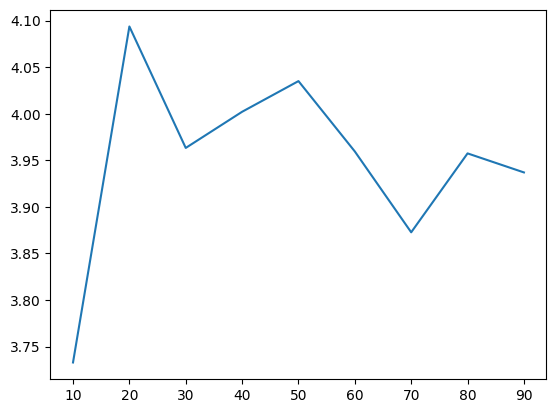

In [ ]:
plt.plot(Nts, ells)

### 2c — Eq. 14 end to end
Everything at once. Only meaningful if 2a and 2b passed; if this fails but they
passed, the fault is in `eps` or `kappa`, not the structure.

In [ ]:
taus = np.linspace(8, 20, 10 )
VRs = np.linspace(3 * D_STEP, 0.6 * B_CELL, 20)

T_sim = np.zeros((len(VRs), len(taus)))
T_theory = np.zeros_like(T_sim)

THETA = np.pi/2

W = 800
for idxv, VR in enumerate(tqdm(VRs)):
    for idxt, tau in enumerate(taus):
        if VR >= tau:
            continue
        T, sem, cens = mfpt_visual_numba(L=L, Nt=Nt, r=r, VR=VR, tau=tau, theta=THETA,
                                W=W, seed=7, rule='dir')
        Tt = T_vis_eq14(tau, VR, r, THETA)

        T_sim[idxv, idxt] = T
        T_theory[idxv, idxt] = Tt


    # bad = []
    # if VR < 3 * D_STEP:  bad.append("VR<3d")
    # if TAU > 0.6 * B_CELL: bad.append("tau>0.6b")
    # if r / B_CELL > 0.1: bad.append("not dilute")
    # print(f"{VR:5.1f} {T:9.1f} {sem:6.1f} {Tt:9.1f} {T/Tt:7.3f} "
    #       f"{'ok' if not bad else ','.join(bad):>28}")

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
taus = np.linspace(8, 20, 10 )
VRs = np.linspace(3 * D_STEP, 0.6 * B_CELL, 20)
T_sim = np.zeros((len(VRs), len(taus)))
T_theory = np.zeros_like(T_sim)

THETA = np.pi/2

W = 800
for idxv, VR in enumerate(tqdm(VRs)):
    for idxt, tau in enumerate(taus):
        # if VR >= tau:
        #     continue
        T, sem, cens = mfpt_visual_numba(L=L, Nt=Nt, r=r, VR=VR, tau=tau, theta=THETA,
                                W=W, seed=7, rule='dir')
        Tt = T_vis_eq14(tau, VR, r, THETA)

        T_sim[idxv, idxt] = T
        T_theory[idxv, idxt] = Tt


    # bad = []
    # if VR < 3 * D_STEP:  bad.append("VR<3d")
    # if TAU > 0.6 * B_CELL: bad.append("tau>0.6b")
    # if r / B_CELL > 0.1: bad.append("not dilute")
    # print(f"{VR:5.1f} {T:9.1f} {sem:6.1f} {Tt:9.1f} {T/Tt:7.3f} "
    #       f"{'ok' if not bad else ','.join(bad):>28}")

  0%|          | 0/20 [00:00<?, ?it/s]

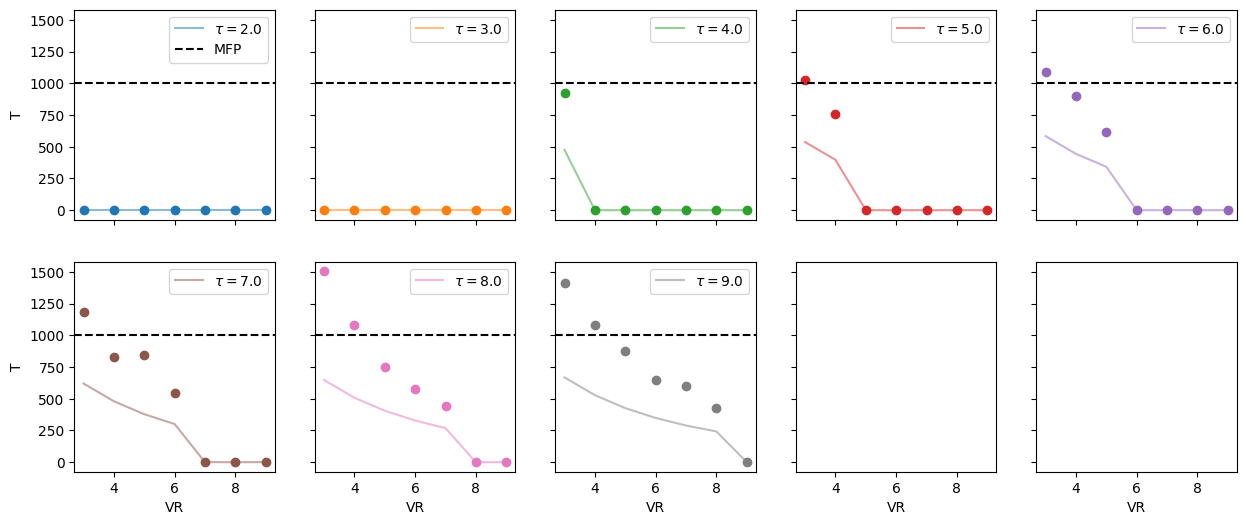

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for idxt, tau in enumerate(taus):
    ax[idxt//5, idxt%5].plot(VRs, T_sim[:, idxt], 'o',  c = f'C{idxt}')
    ax[idxt//5, idxt%5].plot(VRs, T_theory[:, idxt], label=fr'$\tau={tau:.1f}$', alpha = 0.5, c = f'C{idxt}')

    ax[idxt//5, idxt%5].axhline(MFP, color='k', ls='--', label = 'MFP' if idxt==0 else None)
    ax[idxt//5, idxt%5].legend()

plt.setp(ax[:,0], ylabel='T')
plt.setp(ax[1,:], xlabel='VR');
    

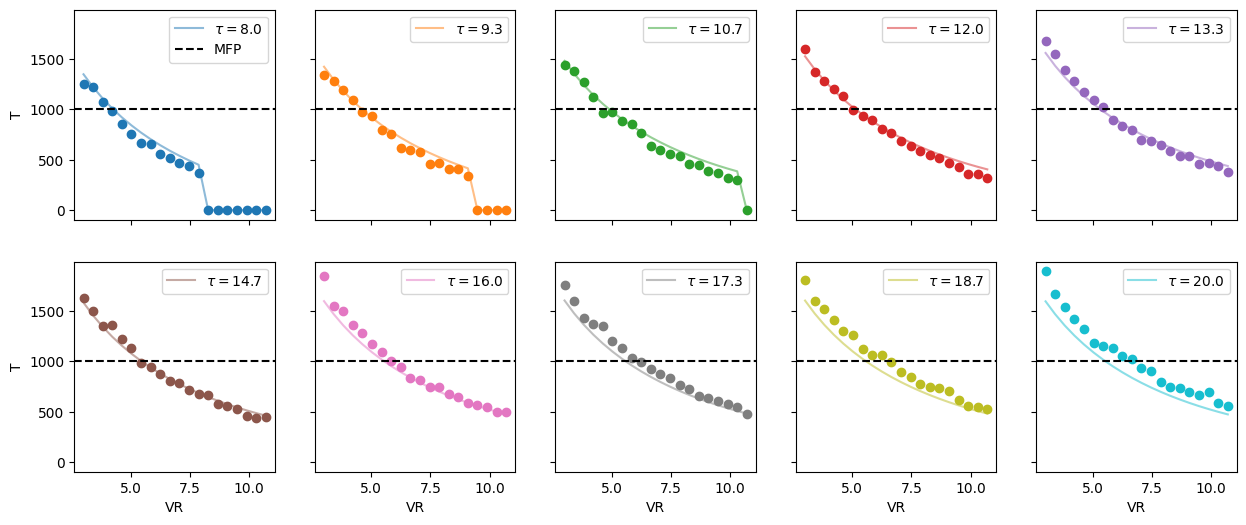

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for idxt, tau in enumerate(taus):
    ax[idxt//5, idxt%5].plot(VRs, T_sim[:, idxt], 'o',  c = f'C{idxt}')
    ax[idxt//5, idxt%5].plot(VRs, T_theory[:, idxt], label=fr'$\tau={tau:.1f}$', alpha = 0.5, c = f'C{idxt}')

    ax[idxt//5, idxt%5].axhline(MFP, color='k', ls='--', label = 'MFP' if idxt==0 else None)
    ax[idxt//5, idxt%5].legend()

plt.setp(ax[:,0], ylabel='T')
plt.setp(ax[1,:], xlabel='VR');
    

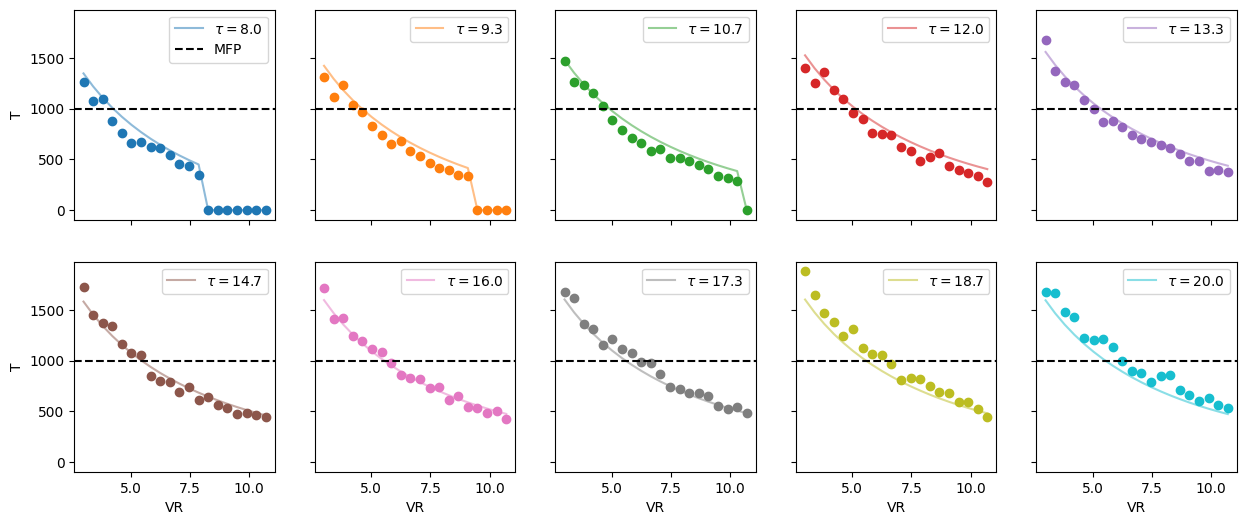

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

for idxt, tau in enumerate(taus):
    ax[idxt//5, idxt%5].plot(VRs, T_sim[:, idxt], 'o',  c = f'C{idxt}')
    ax[idxt//5, idxt%5].plot(VRs, T_theory[:, idxt], label=fr'$\tau={tau:.1f}$', alpha = 0.5, c = f'C{idxt}')

    ax[idxt//5, idxt%5].axhline(MFP, color='k', ls='--', label = 'MFP' if idxt==0 else None)
    ax[idxt//5, idxt%5].legend()

plt.setp(ax[:,0], ylabel='T')
plt.setp(ax[1,:], xlabel='VR');
    

### Checking with `rl_opts`

In [ ]:
from rl_opts.rl_framework.numba.agents import run_collective_target_visual

In [ ]:
episodes = 10; time_ep = 5000
max_counter = 20
state_space = np.array([max_counter, 2, 2])
num_agents = 1
n_runs = 25

tau = 4
VRs = np.linspace(3 * D_STEP, 0.6 * B_CELL, 20)
# VRs = np.linspace(1, 20, 10)
THETA = np.pi/2


h_mat = np.ones((num_agents, 2, 4*max_counter))

# Setting turning when seeing rewarded agent to 0, the rest are 1
h_mat[:, 1, 3*max_counter:] = 0
# # But then for not seeing agents they do pure brownian motion
h_mat[:, 0, :max_counter] = 0

rews_tau_visual = np.zeros((len(VRs), n_runs, num_agents, episodes))
T_theory = np.zeros(len(VRs))

for idx_t, VR in enumerate(tqdm(VRs)):

    T_theory[idx_t] = T_vis_eq14(tau, VR, r, THETA)


    rews, mats = run_collective_target_visual(episodes = episodes, time_ep = time_ep, 
                                                runs=n_runs,
                                                # Environment props
                                                Nt=Nt,
                                                L=L,
                                                r=r,
                                                tau=tau,
                                                num_agents=num_agents,
                                                agent_step=1,
                                                shared_depletion=False,
                                                visual_activated = True,
                                                visual_range = VR, visual_angle = THETA,
                                                # Agent props
                                                num_actions=2,
                                                state_space=state_space,
                                                gamma_damping=0, 
                                                eta_glow_damping=1,
                                                initial_h_0 = True,
                                                h_0 = h_mat,
                                                no_learning = True
                                                )
    
    rews_tau_visual[idx_t] = rews/time_ep

  0%|          | 0/20 [00:00<?, ?it/s]

SystemError: CPUDispatcher(<function run_collective_target_visual at 0x7b5c77517880>) returned a result with an exception set

<ErrorbarContainer object of 3 artists>

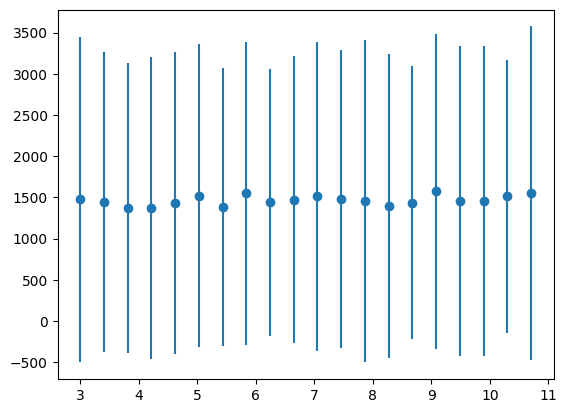

In [ ]:
plt.errorbar(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual, axis=(1, 2, 3)), fmt = 'o', label = 'sim')


[<matplotlib.lines.Line2D>]

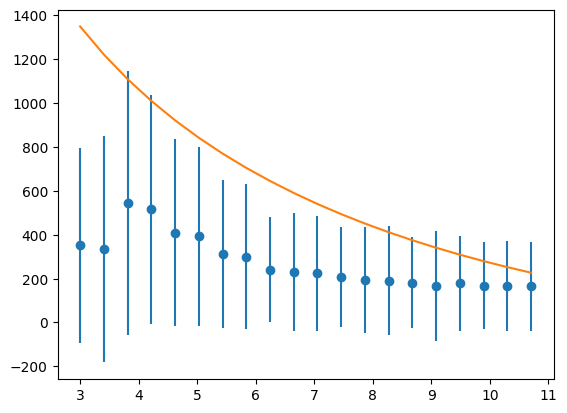

In [ ]:
plt.errorbar(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual, axis=(1, 2, 3)), fmt = 'o', label = 'sim')
plt.plot(VRs, T_theory, label = 'theory')

[<matplotlib.lines.Line2D>]

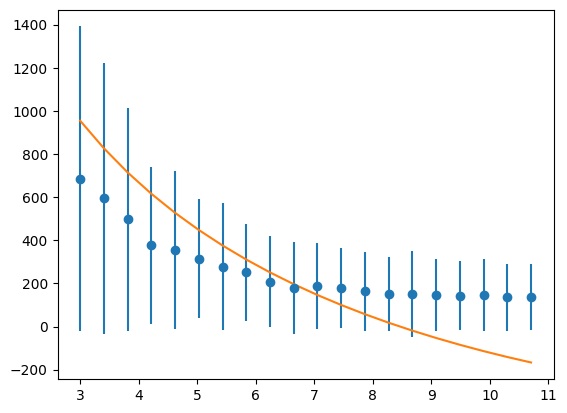

In [ ]:
plt.errorbar(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual, axis=(1, 2, 3)), fmt = 'o', label = 'sim')
plt.plot(VRs, T_theory, label = 'theory')

<matplotlib.legend.Legend>

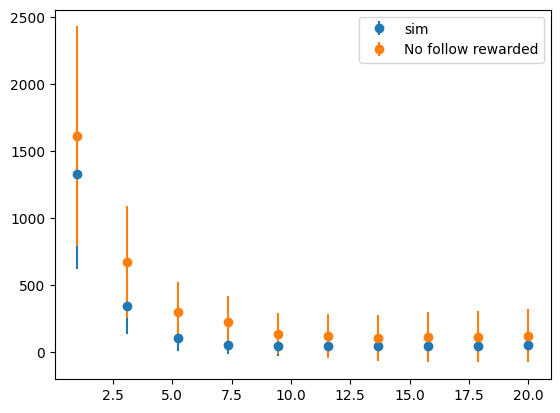

In [ ]:
plt.errorbar(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual, axis=(1, 2, 3)), fmt = 'o', label = 'sim')
plt.errorbar(VRs, 1/np.mean(rews_tau_visual_0, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual_0, axis=(1, 2, 3)), fmt = 'o', label = 'No follow rewarded')
plt.legend()

<ErrorbarContainer object of 3 artists>

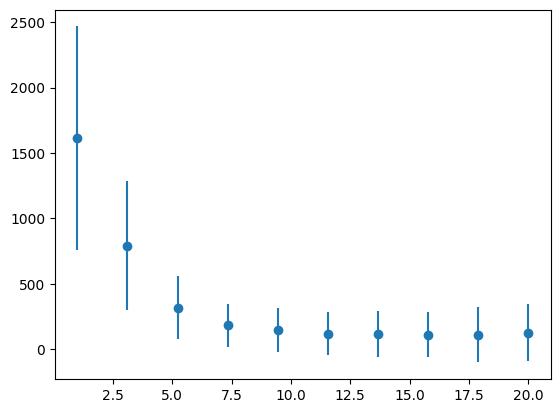

In [ ]:
plt.errorbar(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual, axis=(1, 2, 3)), fmt = 'o', label = 'sim')

<ErrorbarContainer object of 3 artists>

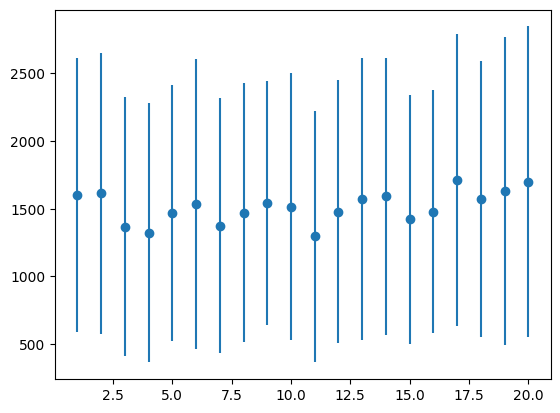

In [ ]:
plt.errorbar(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)), yerr = 1/np.std(rews_tau_visual, axis=(1, 2, 3)), fmt = 'o', label = 'sim')

[<matplotlib.lines.Line2D>]

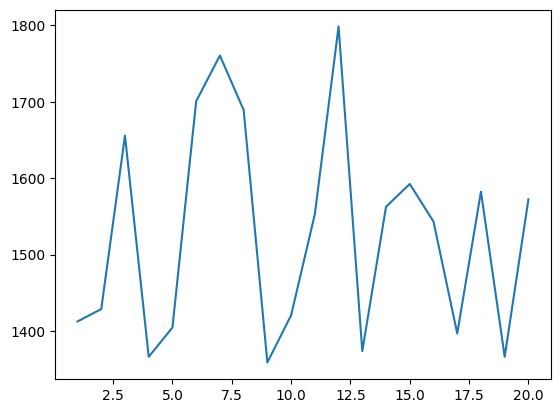

In [ ]:
plt.plot(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)))

[<matplotlib.lines.Line2D>]

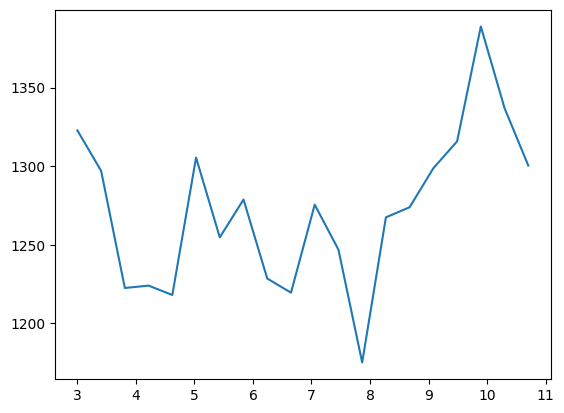

In [ ]:
plt.plot(VRs, 1/np.mean(rews_tau_visual, axis=(1, 2, 3)))

# CHECK 3 — Eq. 18 (T_blind)

Scan `tau` and fit `T = T_inf*(1 - B*(r/tau)^psi)`. Three things to check:
1. `T_inf` vs the analytic MFP `1/(2*r*rho)`;
2. `psi = 1` (ballistic branch, DERIVED) against `psi = 2`;
3. `B` — but note **B is not universal**: it is 0.38 for a fixed-policy pure
   ballistic walker and 0.73 for the *optimised* biexponential. Pick the walker
   you mean. Below, `POLICY='pure'` tests the derivation cleanly (fixed policy
   = no confound between the prefactor's tau-dependence and a tau-dependent
   change of strategy). `POLICY='optimised'` tests what the phase map uses.

**Sample small tau.** The whole content of Eq. 18 is the `(r/tau)` correction,
which is spent by `tau ~ 2`. A scan starting at `tau=4` is ~flat and tests
nothing.


CHECK 3 — Eq. 18   (POLICY = optimised)

  tau=  0.6  best wl=0.050
  tau=  0.6  T=  417.41 +- 15.78  cens=0.000
  tau=  1.0  best wl=0.020
  tau=  1.0  T=  654.21 +- 22.55  cens=0.000
  tau=  1.5  best wl=0.020
  tau=  1.5  T=  733.65 +- 19.92  cens=0.000
  tau=  2.0  best wl=0.020
  tau=  2.0  T=  809.38 +- 20.82  cens=0.001
  tau=  3.0  best wl=0.020
  tau=  3.0  T=  878.11 +- 20.64  cens=0.000
  tau=  5.0  best wl=0.050
  tau=  5.0  T=  931.64 +- 19.86  cens=0.000
  tau=  8.0  best wl=0.200
  tau=  8.0  T=  964.83 +- 21.22  cens=0.000
  tau= 12.0  best wl=0.600
  tau= 12.0  T=  973.80 +- 20.36  cens=0.000
  tau= 20.0  best wl=0.100
  tau= 20.0  T=  979.04 +- 19.91  cens=0.000
  tau= 30.0  best wl=0.000
  tau= 30.0  T= 1002.08 +- 19.63  cens=0.000

  psi=1:  T_inf=  999.3  B=0.707  R2=0.9951   (MFP=1000.0, T_inf/MFP=0.999)

  psi=2:  T_inf=  928.7  B=0.838  R2=0.8832   (MFP=1000.0, T_inf/MFP=0.929)

  expect psi=1 to win. reference (rho=1e-3, pure): T_inf=1034, B=0.38, R2=0.949
   

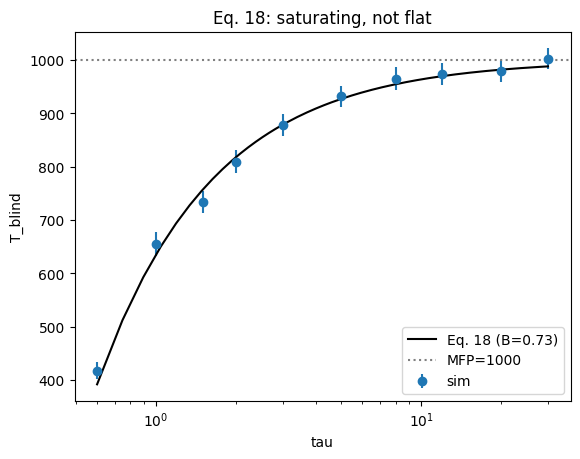

In [ ]:
POLICY = 'optimised'          # 'pure' or 'optimised'
D1 = 20 * MFP

def blind_T(tau, W=2500, h=0.2, seed=7):
    if POLICY == 'pure':
        return run_flight(L, Nt, r, tau, [tau, D1], [0.0, 1.0], W=W, seed=seed, h=h)
    best = (np.inf, np.nan, np.nan)
    for wl in tqdm([0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.6, 1.0]):
        m, s, f = run_flight(L, Nt, r, tau, [tau, D1], [1-wl, wl], W=W, seed=seed, h=h)
        if m < best[0]:
            best = (m, s, f)
            best_wl = wl
    print(f"  tau={tau:5.1f}  best wl={best_wl:.3f}")
    return best

print(f"\nCHECK 3 — Eq. 18   (POLICY = {POLICY})\n")
taus_b = np.array([0.6, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 30.0])
taus_b = taus_b[taus_b < L / 3]
Tb, Sb = [], []
for t in taus_b:
    m, s, f = blind_T(float(t))
    Tb.append(m); Sb.append(s)
    print(f"  tau={t:5.1f}  T={m:8.2f} +- {s:5.2f}  cens={f:.3f}")
Tb, Sb = np.array(Tb), np.array(Sb)

for psi_try in (1.0, 2.0):
    f = lambda tau, Tinf, B: Tinf * (1 - B * (r / tau) ** psi_try)
    try:
        popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
        pred = f(taus_b, *popt)
        R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)
        print(f"\n  psi={psi_try:.0f}:  T_inf={popt[0]:7.1f}  B={popt[1]:.3f}  R2={R2:.4f}"
              f"   (MFP={MFP:.1f}, T_inf/MFP={popt[0]/MFP:.3f})")
    except Exception as e:
        print(f"  psi={psi_try}: fit failed: {e}")
print(f"\n  expect psi=1 to win. reference (rho=1e-3, pure): T_inf=1034, B=0.38, R2=0.949")
print(f"                        (rho=1e-3, optimised):      T_inf=1011, B=0.73, R2=0.967")



plt.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')
tt = np.linspace(taus_b.min(), taus_b.max(), 200)
plt.plot(tt, T_blind_eq18(tt, r, B=B_PURE if POLICY == 'pure' else B_OPT),
         'k-', label=f'Eq. 18 (B={B_PURE if POLICY=="pure" else B_OPT})')
plt.axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')
plt.xscale('log'); plt.xlabel('tau'); plt.ylabel('T_blind'); plt.legend()
plt.title('Eq. 18: saturating, not flat'); plt.show()


In [ ]:
np.linspace(50, 100, 6)

array([ 50.,  60.,  70.,  80.,  90., 100.])

In [ ]:
POLICY = 'optimised'          # 'pure' or 'optimised'

Ls = np.linspace(50, 100, 6)
W = 5000

mftp_Ls = []
sigma_Ls = []
for L in tqdm(Ls):
    Nt, r = 10, 0.5
    rho = Nt / L**2
    A = 2 / (np.pi * rho)
    B_CELL = 1 / np.sqrt(np.pi * rho)
    MFP = 1 / (2 * r * rho)
    D1 = 20 * MFP
    

    def blind_T(tau, W=W, h=0.2, seed=7):
        if POLICY == 'pure':
            return run_flight_numba(L, Nt, r, tau, [tau, D1], [0.0, 1.0], W=W, seed=seed, h=h)
        best = (np.inf, np.nan, np.nan)
        for wl in (np.linspace(0, 1, 20)):

            m_run, s_run, f_run = 0.0, 0.0, 0.0
            runs = 15
            for _ in range(runs):
                m, s, f = run_flight_numba(L, Nt, r, tau, [tau, D1], [1-wl, wl], W=W, seed=seed, h=h)
                m_run += m / runs
                s_run += s / runs
                f_run += f / runs

            if m_run < best[0]:
                best = (m_run, s_run, f_run)
                best_wl = wl
                print(f"  tau={tau:5.1f}  best wl={best_wl:.3f}")
                
        return best

    taus_b = np.logspace(np.log10(0.6), np.log10(L/3), 20)
    taus_b = taus_b[taus_b < L / 3]
    Tb, Sb = [], []
    for t in tqdm(taus_b):
        m, s, f = blind_T(float(t))
        Tb.append(m); Sb.append(s)
    Tb, Sb = np.array(Tb), np.array(Sb)

    mftp_Ls.append(Tb)
    sigma_Ls.append(Sb)


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
for m, s, l in zip(mftp_Ls, sigma_Ls, Ls):
    np.save(f"../paper/data/blind_mftp_avg_L{l:.0f}_Nt_{Nt:.0f}_r_{r:.0f}.npy", m)
    np.save(f"../paper/data/blind_mftp_sem_L{l:.0f}_Nt_{Nt:.0f}_r_{r:.0f}.npy", s)


  psi=2:  A=    1.1  B=0.649  R2=0.9758   (MFP=1000.0


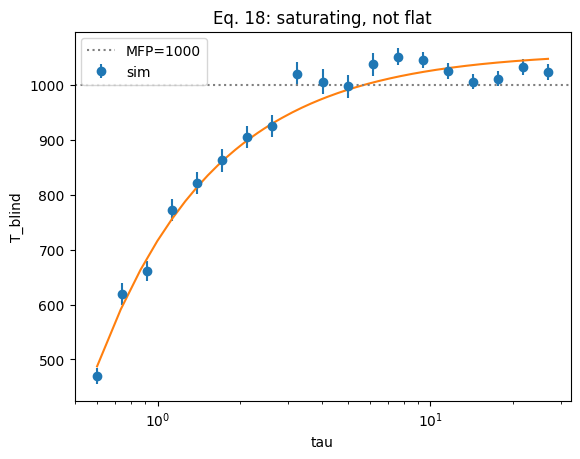

In [ ]:
f = lambda tau, A, B: A*MFP * (1 - B * (r / tau))
try:
    popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
    pred = f(taus_b, *popt)
    R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)
    print(f"\n  psi={psi_try:.0f}:  A={popt[0]:7.1f}  B={popt[1]:.3f}  R2={R2:.4f}"
            f"   (MFP={MFP:.1f}")
except Exception as e:
    print(f"  psi={psi_try}: fit failed: {e}")


plt.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')
tt = np.linspace(taus_b.min(), taus_b.max(), 200)
plt.plot(tt, T_blind_eq18(tt, r, T_inf = popt[0]*MFP, B=popt[1]))
# plt.plot(tt, f(tt, *popt))



plt.axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')



plt.xscale('log'); plt.xlabel('tau'); plt.ylabel('T_blind'); plt.legend()
plt.title('Eq. 18: saturating, not flat'); plt.show()


  psi=2:  A=    1.0  B=0.636  R2=0.9399   (MFP=490.0


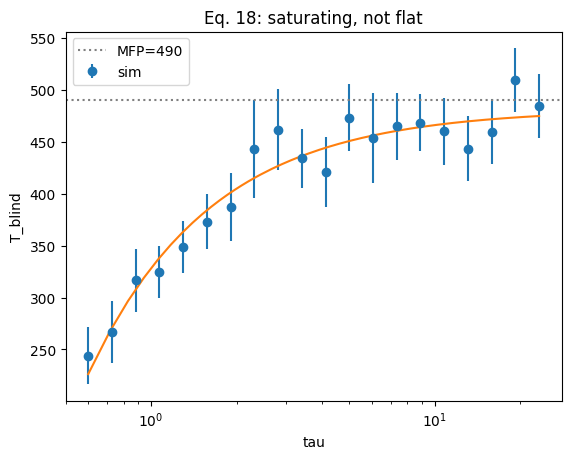

In [ ]:
f = lambda tau, A, B: A*MFP * (1 - B * (r / tau))
try:
    popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
    pred = f(taus_b, *popt)
    R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)
    print(f"\n  psi={psi_try:.0f}:  A={popt[0]:7.1f}  B={popt[1]:.3f}  R2={R2:.4f}"
            f"   (MFP={MFP:.1f}")
except Exception as e:
    print(f"  psi={psi_try}: fit failed: {e}")


plt.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')
tt = np.linspace(taus_b.min(), taus_b.max(), 200)
plt.plot(tt, T_blind_eq18(tt, r, T_inf = popt[0]*MFP, B=popt[1]))
# plt.plot(tt, f(tt, *popt))



plt.axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')



plt.xscale('log'); plt.xlabel('tau'); plt.ylabel('T_blind'); plt.legend()
plt.title('Eq. 18: saturating, not flat'); plt.show()

[None, None, None, None, None, None]

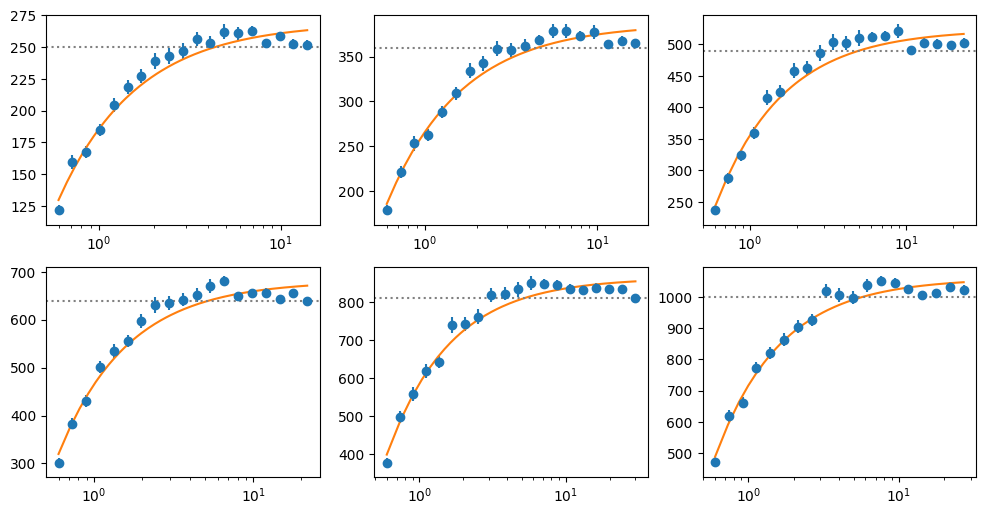

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(3*4, 2*3))

for idxL, (Tb, Sb, L) in enumerate(zip(mftp_Ls, sigma_Ls, Ls)):

    rho = Nt / L**2
    A = 2 / (np.pi * rho)
    B_CELL = 1 / np.sqrt(np.pi * rho)
    MFP = 1 / (2 * r * rho)
    taus_b = np.logspace(np.log10(0.6), np.log10(L/3), 20)
    taus_b = taus_b[taus_b < L / 3]

    f = lambda tau, A, B: A*MFP * (1 - B * (r / tau))

    popt, _ = curve_fit(f, taus_b, Tb, p0=[MFP, 0.4], sigma=Sb, maxfev=20000)
    pred = f(taus_b, *popt)
    R2 = 1 - np.sum((Tb - pred)**2) / np.sum((Tb - Tb.mean())**2)


    axs.flatten()[idxL].errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')
    tt = np.linspace(taus_b.min(), taus_b.max(), 200)
    axs.flatten()[idxL].plot(tt, T_blind_eq18(tt, r, T_inf = popt[0]*MFP, B=popt[1]))

    axs.flatten()[idxL].axhline(MFP, color='grey', ls=':', label=f'MFP={MFP:.0f}')

    axs.flatten()[idxL]



plt.setp(axs,  xscale = 'log')

# ; plt.xlabel('tau'); plt.ylabel('T_blind'); plt.legend()
# plt.title('Eq. 18: saturating, not flat'); plt.show()

### Optimizing w.r.t. $\lambda$ and $w$

In [ ]:
L, Nt, r = 150, 8, 0.5
tau = 2.0; seed = 7; h = 0.2
lambdas = np.linspace(0.5, 4, 10)
wls = np.linspace(0, 1, 10)
eff_l_w = np.zeros((len(lambdas), len(wls)))
for idxl, lmb in enumerate(tqdm(lambdas)):
    for idxw, wl in enumerate(wls):
        m, _, _ = run_flight(L, Nt, r, tau, [lmb, 3*L], [1-wl, wl], W=1000, seed=seed)
        eff_l_w[idxl, idxw] = m

  0%|          | 0/10 [00:00<?, ?it/s]

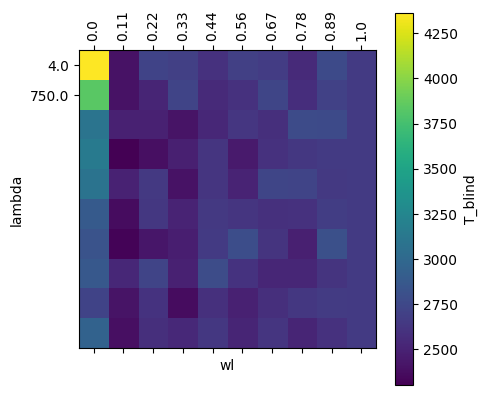

In [ ]:
plt.matshow(eff_l_w)
plt.ylabel('lambda'); plt.xlabel('wl');
plt.xticks(ticks=np.arange(len(wls)), labels=np.round(wls, 2), rotation=90)
plt.yticks(ticks=np.arange(len(lambdas)), labels=np.round(lambdas, 2));
plt.colorbar(label='T_blind');

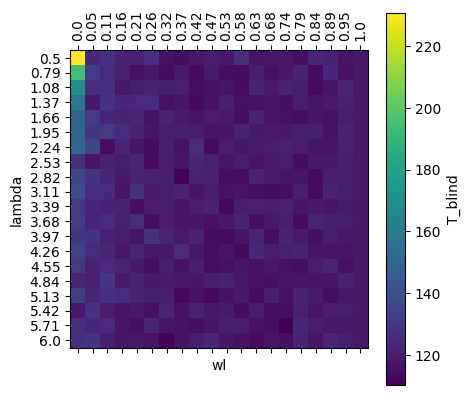

In [ ]:
plt.matshow(eff_l_w)
plt.ylabel('lambda'); plt.xlabel('wl');
plt.xticks(ticks=np.arange(len(wls)), labels=np.round(wls, 2), rotation=90)
plt.yticks(ticks=np.arange(len(lambdas)), labels=np.round(lambdas, 2));
plt.colorbar(label='T_blind');

In [ ]:
L, Nt, r = 150, 8, 0.5
b = 1/np.sqrt(np.pi*Nt/L**2)
for tau in [2, 4, 8]:
    Ts = [run_flight(L,Nt,r,tau,[tau,3*L],[1-w,w],W=2000,seed=7,h=0.2)[0]
          for w in [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]]
    print(f"tau={tau} (tau/b={tau/b:.2f})  intensive={Ts[0]:.0f}  "
          f"ballistic={Ts[-1]:.0f}  best={min(Ts):.0f}  argmin w={[0,.05,.1,.2,.5,1][Ts.index(min(Ts))]}")

tau=2 (tau/b=0.07)  intensive=3091  ballistic=2603  best=2334  argmin w=0.05
tau=4 (tau/b=0.13)  intensive=3029  ballistic=2771  best=2622  argmin w=0.05


KeyboardInterrupt: 

### Checking with `rl_opts`

In [ ]:
from rl_opts.analytics import get_policy_from_dist, pdf_powerlaw, pdf_multimode
from rl_opts.rl_framework.numba.agents import run_collective


In [ ]:
time_ep = 5000; episodes = 100
max_counter = 500
num_agents = 20
n_runs = 25

wls = np.array([0.050, 0.020, 0.020, 0.020, 0.020, 0.050, 0.200, 0.600, 0.100, 0.000])
taus = np.array([0.6, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 30.0])

rews_tau = np.zeros((len(taus), n_runs, num_agents, episodes))

for idx_t, (tau, wl) in enumerate(zip(taus, tqdm(wls))):

    policy = get_policy_from_dist(n_max=max_counter,
                                        func = pdf_multimode,
                                        lambdas = np.array([tau, D1]),
                                        probs = np.array([1-wl, wl])
                                    )
    policy = np.array(policy)

    # We will use the visual type of simulations. Because there we have 4 different visual percepts, we account for this. 
    # Then, no seen agents is at the beginning of the matrix
    num_agents = 20
    h_mat = np.zeros((num_agents, 2, 4*max_counter))

    h_mat[:, 0, :max_counter] = policy
    h_mat[:, 1, :max_counter] = 1-policy

    state_space = np.array([max_counter, 2, 2])

    rews, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                runs=n_runs,
                                # Environment props
                                Nt=Nt,
                                L=L,
                                r=r,
                                tau=tau,
                                num_agents=num_agents,
                                agent_step=1,
                                shared_depletion=False,
                                visual_activated = False,
                                # Agent props
                                num_actions=2,
                                state_space=state_space,
                                gamma_damping=0, 
                                eta_glow_damping=1,
                                initial_h_0 = True,
                                h_0 = h_mat,
                                no_learning = True
                                )
    
    rews_tau[idx_t] = rews/time_ep

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
T_numerics = 1/rews_tau.mean(-1).copy()

<ErrorbarContainer object of 3 artists>

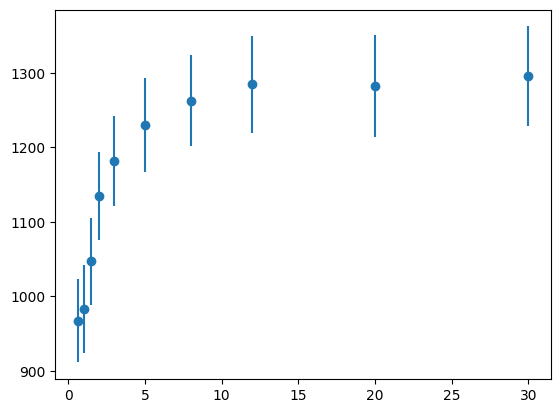

In [ ]:
plt.errorbar(taus, np.mean(T_numerics, axis=(1,2)), yerr=np.std(T_numerics, axis=(1,2)), fmt='o', label='theory')

# plt.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')

# 4. Crossover with rl_opts

In [ ]:
from rl_opts.analytics import get_policy_from_dist, pdf_powerlaw, pdf_multimode
from rl_opts.rl_framework.numba.agents import run_collective_target_visual, train_loop_collective_target_visual, run_collective


In [ ]:
episodes = 10; time_ep = 2500
max_counter = 50
state_space = np.array([max_counter, 2, 2])
num_agents_visual = 1

num_agents_blind = 100
n_runs = 35

VRs = np.linspace(1, 20, 10)
THETA = np.pi/2

taus = np.array([0.6, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0, 30.0])

# Blind (semi) optimal parameter
wls = np.array([0.050, 0.020, 0.020, 0.020, 0.020, 0.050, 0.200, 0.600, 0.100, 0.000])

In [ ]:
rews_blind = np.zeros((len(taus), n_runs, num_agents_blind, episodes))

for idx_t, (tau, wl) in enumerate(zip(taus, tqdm(wls))):

    policy = get_policy_from_dist(n_max=max_counter,
                                        func = pdf_multimode,
                                        lambdas = np.array([tau, 5*L]),
                                        probs = np.array([1-wl, wl])
                                    )
    policy = np.array(policy)

    # We will use the visual type of simulations. Because there we have 4 different visual percepts, we account for this. 
    # Then, no seen agents is at the beginning of the matrix
    
    h_mat = np.zeros((num_agents_blind, 2, 4*max_counter))

    h_mat[:, 0, :max_counter] = policy
    h_mat[:, 1, :max_counter] = 1-policy


    rews, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                runs=n_runs,
                                # Environment props
                                Nt=Nt,
                                L=L,
                                r=r,
                                tau=tau,
                                num_agents=num_agents_blind,
                                agent_step=1,
                                shared_depletion=False,
                                visual_activated = False,
                                # Agent props
                                num_actions=2,
                                state_space=state_space,
                                gamma_damping=0, 
                                eta_glow_damping=1,
                                initial_h_0 = True,
                                h_0 = h_mat,
                                no_learning = True
                                )
    
    rews_blind[idx_t] = rews/time_ep

  0%|          | 0/10 [00:00<?, ?it/s]

<ErrorbarContainer object of 3 artists>

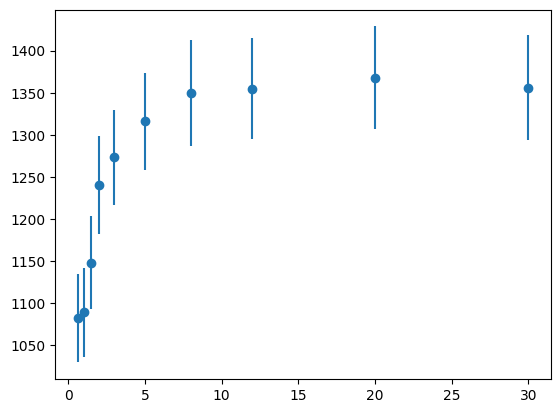

In [ ]:
T_numerics = 1/rews_blind.mean(-1).copy()
plt.errorbar(taus, np.mean(T_numerics, axis=(1,2)), yerr=np.std(T_numerics, axis=(1,2))/np.sqrt(n_runs), fmt='o', label='theory')

# plt.errorbar(taus_b, Tb, yerr=Sb, fmt='o', label='sim')

In [ ]:
##### VISUAL #####
rews_visual = np.zeros((len(taus), len(VRs), n_runs, num_agents_visual, episodes))

for idx_t, tau in enumerate(tqdm(taus)):    
    for idx_vr, VR in enumerate(tqdm(VRs)):

        h_mat_vis = np.ones((num_agents_visual, 2, 4*max_counter))
        # Setting turning when seeing rewarded agent to 0, the rest are 1
        h_mat_vis[:, 1, 3*max_counter:] = 0
        # # But then for not seeing agents they do pure brownian motion
        h_mat_vis[:, 0, :max_counter] = 0        


        rews, mats = run_collective_target_visual(episodes = episodes, time_ep = time_ep, 
                                                    runs=n_runs,
                                                    # Environment props
                                                    Nt=Nt,
                                                    L=L,
                                                    r=r,
                                                    tau=tau,
                                                    num_agents=num_agents_visual,
                                                    agent_step=1,
                                                    shared_depletion=False,
                                                    visual_activated = True, # VISUAL ACTIVATED!
                                                    visual_range = VR, visual_angle = THETA,
                                                    # Agent props
                                                    num_actions=2,
                                                    state_space=state_space,
                                                    initial_h_0 = True,
                                                    h_0 = h_mat_vis,
                                                    no_learning = True
                                                    )
        
        rews_visual[idx_t, idx_vr] = rews/time_ep

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
avgT_blind = 1/np.mean(rews_blind, axis = (1,2,3))
avgT_visual = 1/np.mean(rews_visual, axis = (2,3,4))

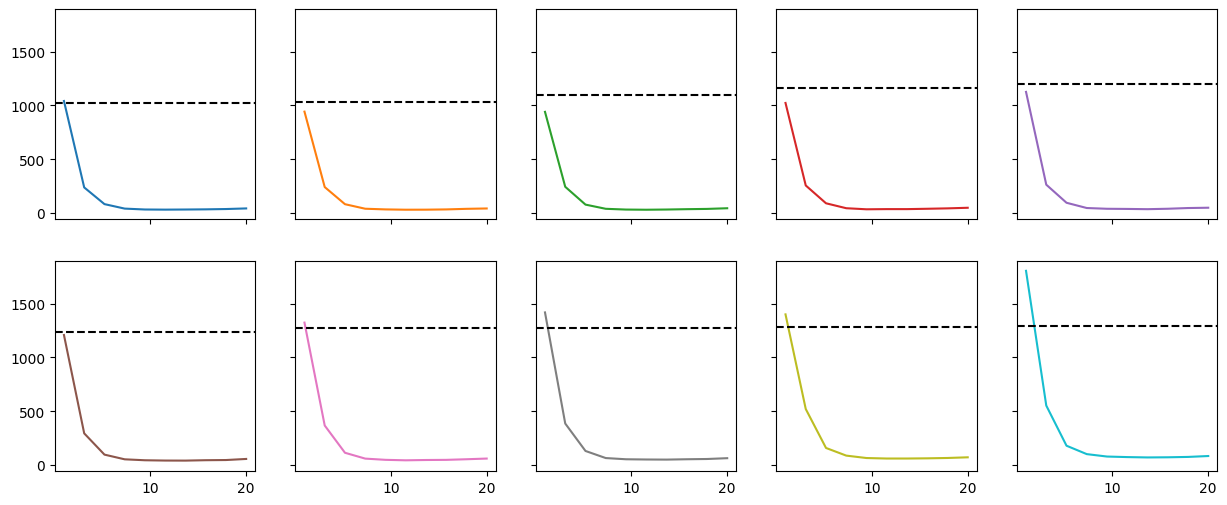

In [ ]:
fig, ax = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)
for idxt, tau in enumerate(taus):
    ax.flatten()[idxt].plot(VRs, avgT_visual[idxt], c = f'C{idxt}')
    ax.flatten()[idxt].axhline(avgT_blind[idxt], c = 'k', ls = '--')

In [ ]:
39

array([ 0.6,  1. ,  1.5,  2. ,  3. ,  5. ,  8. , 12. , 20. , 30. ])

In [ ]:
avgT_blind = 1/np.mean(rews_blind, axis = (1,2,3))
avgT_visual = 1/np.mean(rews_visual, axis = (2,3,4))

best = np.zeros((len(taus), len(VRs)))
for idxv, VR in enumerate(VRs):
    for idxt, tau in enumerate(taus):
        best[idxt, idxv] = 1 if avgT_blind[idxt] < avgT_visual[idxt, idxv] else 0

Text(0.5, 1.0, '1=blind better, 0=visual better')

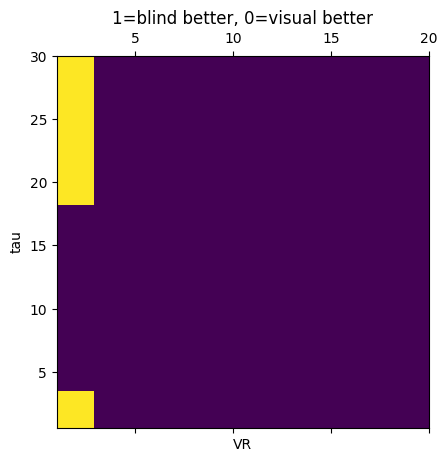

In [ ]:
plt.matshow(best, extent=[VRs.min(), VRs.max(), taus.min(), taus.max()], origin='lower', aspect='auto')
plt.xlabel('VR'); plt.ylabel('tau'); plt.title('1=blind better, 0=visual better')

# Bayesian search for blind

In [ ]:
#| eval: false
from rl_opts.rl_framework.numba.agents import run_collective
from rl_opts.analytics import get_policy_from_dist, pdf_powerlaw, pdf_multimode

from ray import tune
from ray.tune.search.bayesopt import BayesOptSearch
from ray.tune.search.optuna import OptunaSearch
from ray.tune.search import ConcurrencyLimiter
from ray.tune import RunConfig
import numpy as np

import time

In [ ]:
NUM_AGENTS = 100
N_RUNS = 45
MAX_COUNTER = 100
STATE_SPACE = np.array([MAX_COUNTER, 2, 2])

L, Nt, r = 50, 20, 0.5
taus = np.arange(2, 12)



import os
path_ray = "/sata1/gorka/collective/ray_results"
os.makedirs(path_ray, exist_ok=True)


In [ ]:
for tau in taus:

    time_start = time.time()

    config = {'episodes': 100, 
                'time_ep': 5000, 
                'Nt': Nt, 
                'L': L, 
                'r': r, 
                'tau': tau,
                'lambda1': tune.uniform(tau/4, 2*tau), 
                'wl': tune.uniform(0,0.5),
                'num_raytune_samples': 100,
                'max_counter': MAX_COUNTER,
                'num_agents': NUM_AGENTS,
                'n_runs': N_RUNS,
                'state_space': STATE_SPACE}

    search = OptunaSearch(metric="mean_eff", mode="max")
    search = ConcurrencyLimiter(search, max_concurrent=1)

    tuner = tune.Tuner(
                average_search_efficiency,
                tune_config=tune.TuneConfig(search_alg=search, num_samples=100, reuse_actors=True),
                run_config=RunConfig(name=f"average_search_efficiency_tau{tau}_Nt{Nt}_L{L}_r{r}",
                                    storage_path="/sata1/gorka/collective/ray_results",
                                    verbose = 0
                                ),
                param_space=config,
            )
    
    result_grid = tuner.fit()

    print(f"Finished tau={tau} in {time.time()-time_start:.1f} seconds")

2026-07-21 11:03:20,804	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2026-07-21 11:03:20,808	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/sata1/gorka/collective/ray_results/average_search_efficiency_tau8_Nt20_L50_r0.5' in 0.0035s.
*** SIGTERM received at time=1784624603 on cpu 7 ***
PC: @     0x7616f4691117  (unknown)  (unknown)
    @     0x7616f4642520  (unknown)  (unknown)
    @ ... and at least 1 more frames
[2026-07-21 11:03:23,299 E 2497219 2497219] logging.cc:474: *** SIGTERM received at time=1784624603 on cpu 7 ***
[2026-07-21 11:03:23,300 E 2497219 2497219] logging.cc:474: PC: @     0x7616f4691117  (unknown)  (unknown)
[2026-07-21 11:03:23,300 E 2497219 2497219] logging.cc:474:     @     0x7616f4642520  (unknown)  (unknown)
[2026-07-21 11:03:23,300 E 2497219 2497219] l

SystemExit: 1

/home/gorka/miniconda3/envs/rl_opts/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


2026-07-21 08:51:13,472	ERROR tune_controller.py:1332 -- Trial task failed for trial average_search_efficiency_c1a7a59a
Traceback (most recent call last):
  File "/home/gorka/miniconda3/envs/rl_opts/lib/python3.11/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/home/gorka/miniconda3/envs/rl_opts/lib/python3.11/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/gorka/miniconda3/envs/rl_opts/lib/python3.11/site-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/gorka/miniconda3/envs/rl_opts/lib/python3.11/site-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/home/gorka/mi

In [ ]:
restored_tuner = tune.Tuner.restore(
    '/home/gorka/ray_results/average_search_efficiency_2026-07-20_16-47-08',
    trainable=average_search_efficiency,
)

results = restored_tuner.get_results()

### Analysis

In [ ]:
df = result_grid.get_dataframe()

In [ ]:
df.keys()

Index(['mean_eff', 'timestamp', 'checkpoint_dir_name', 'done',
       'training_iteration', 'trial_id', 'date', 'time_this_iter_s',
       'time_total_s', 'pid', 'hostname', 'node_ip', 'time_since_restore',
       'iterations_since_restore', 'config/episodes', 'config/time_ep',
       'config/Nt', 'config/L', 'config/r', 'config/tau', 'config/lambda1',
       'config/wl', 'config/num_raytune_samples', 'config/max_counter',
       'config/num_agents', 'config/n_runs', 'config/state_space', 'logdir'],
      dtype='str')

<matplotlib.collections.PathCollection>

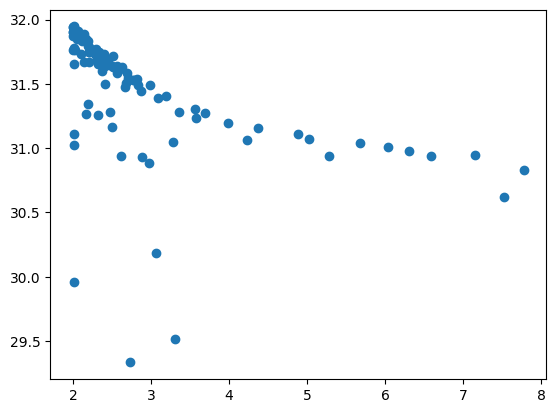

In [ ]:
plt.scatter(df['config/lambda1'], df['mean_eff'])

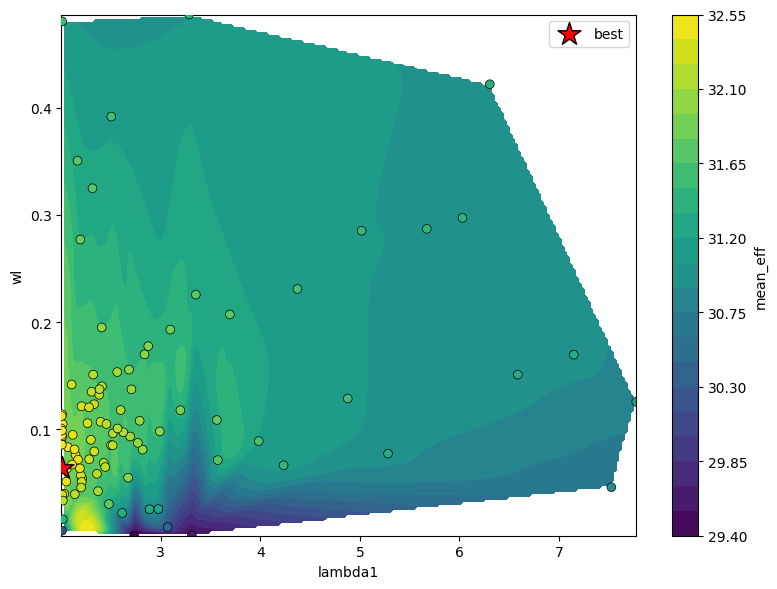

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# results is your ResultGrid from before
df = result_grid.get_dataframe()

x = df["config/lambda1"].values
y = df["config/wl"].values
z = df["mean_eff"].values  # your optimized metric

# Build a grid over the sampled range
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)
xi, yi = np.meshgrid(xi, yi)

# Interpolate z values onto that grid
zi = griddata((x, y), z, (xi, yi), method="cubic")

fig, ax = plt.subplots(figsize=(8, 6))

# Background: interpolated surface
contour = ax.contourf(xi, yi, zi, levels=20, cmap="viridis")
fig.colorbar(contour, ax=ax, label="mean_eff")

# Foreground: actual sampled points
ax.scatter(x, y, c=z, cmap="viridis", edgecolor="black", linewidth=0.5, s=40, zorder=3)

# Mark the best point
best = result_grid.get_best_result(metric="mean_eff", mode="max")
ax.scatter(best.config["lambda1"], best.config["wl"], c="red", marker="*", s=300,
           edgecolor="black", linewidth=1, zorder=4, label="best")

ax.set_xlabel("lambda1")
ax.set_ylabel("wl")
ax.legend()
plt.tight_layout()
plt.savefig("tune_landscape.png", dpi=150)
plt.show()

In [ ]:
df = results.get_dataframe()

In [ ]:
best = results.get_best_result(metric="mean_eff", mode="max")
print(best.config)     # the hyperparameters that won
print(best.metrics)    # the reported metrics for that trial

{'episodes': 100, 'time_ep': 5000, 'Nt': 100, 'L': 100, 'r': 0.5, 'tau': 4, 'lambda1': 2.9361118426546193, 'wl': 0.15599452033620265, 'num_raytune_samples': 100, 'max_counter': 100, 'num_agents': 100, 'n_runs': 40, 'state_space': array([100,   2,   2])}
{'mean_eff': 39.6749825, 'timestamp': 1784559013, 'checkpoint_dir_name': None, 'done': True, 'training_iteration': 1, 'trial_id': '08dcbdc6', 'date': '2026-07-20_16-50-13', 'time_this_iter_s': 57.37332773208618, 'time_total_s': 57.37332773208618, 'pid': 2322583, 'hostname': 'gpu-ada-qic', 'node_ip': '138.232.67.176', 'config': {'episodes': 100, 'time_ep': 5000, 'Nt': 100, 'L': 100, 'r': 0.5, 'tau': 4, 'lambda1': 2.9361118426546193, 'wl': 0.15599452033620265, 'num_raytune_samples': 100, 'max_counter': 100, 'num_agents': 100, 'n_runs': 40, 'state_space': array([100,   2,   2])}, 'time_since_restore': 57.37332773208618, 'iterations_since_restore': 1, 'experiment_tag': '3_L=100,Nt=100,episodes=100,lambda1=2.9361,max_counter=100,n_runs=40,nu

## Search function

In [ ]:
def average_search_efficiency(config, mats = None):

    import numpy as np
    from ray import tune
    from rl_opts.analytics import get_policy_from_dist, pdf_multimode
    from rl_opts.rl_framework.numba.agents import run_collective

    episodes = config['episodes']; time_ep = config['time_ep']
    Nt = config['Nt']; L = config['L']; r = config['r']; tau = config['tau'];        

    wl = config['wl']; lambda1 = config['lambda1']

    max_counter = config['max_counter']
    num_agents  = config['num_agents']
    n_runs      = config['n_runs']
    state_space = config['state_space']

    probs = np.array([1-wl, wl])
    lambdas = np.array([lambda1, 5*L])
    

    if mats is None:
        policy = np.array(get_policy_from_dist(n_max=max_counter,
                                            func = pdf_multimode,
                                            lambdas = lambdas,
                                            probs = probs
                                            ))

        # We will use the visual type of simulations. Because there we have 4 different visual percepts, we account for this. 
        # Then, no seen agents is at the beginning of the matrix    
        h_mat = np.zeros((num_agents, 2, 4*max_counter))
        h_mat[:, 0, :max_counter] = policy
        h_mat[:, 1, :max_counter] = 1-policy
    
    else:
        h_mat = mats.copy()


    rews, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                runs=n_runs,
                                # Environment props
                                Nt=Nt,
                                L=L,
                                r=r,
                                tau=tau,
                                num_agents=num_agents,
                                agent_step=1,
                                shared_depletion=False,
                                visual_activated = False,
                                # Agent props
                                num_actions=2,
                                state_space=state_space,
                                initial_h_0 = True,
                                h_0 = h_mat,
                                no_learning = True
                                )

    mean_eff = np.mean(rews) 
    print(mean_eff/time_ep)
    tune.report({"mean_eff": mean_eff})

In [ ]:
idx = 4
taus = np.arange(2,12)

out_dir = "/sata1/gorka/collective/exp_8"

file_name = f"_shared_False_tau_{taus[idx]}.npy"
h_matrix_path = os.path.join(out_dir, 
                            f"h_matrix"+file_name)

mats = np.load(h_matrix_path)[0]

L, Nt, r = 50, 100, 0.5

max_counter = int(mats.shape[-1]/4)
state_space = np.array([max_counter, 2, 2])

config = {'episodes': 100, 
          'time_ep': 5000, 
          'Nt': Nt, 
          'L': L, 
          'r': r, 
          'tau': taus[idx],
          'lambda1': taus[idx], 
          'wl': 0.01,
          'num_raytune_samples': 100,
          'max_counter': max_counter,
          'num_agents': mats.shape[0],
          'n_runs': 40,
          'state_space': state_space}



average_search_efficiency(config, mats = None)
        

NameError: name 'average_search_efficiency' is not defined

### Sweep over wls

In [ ]:
# L, Nt, r = 300, 90, 0.5

L, Nt, r = 50, 100, 0.5

max_counter = 50
idx_t = 0
num_agents = 50

episodes, time_ep = 10, 5000

tau = taus[idx_t]

wls = np.linspace(0, 0.5, 20)[1:]

rews_wl = np.zeros((len(wls), n_runs, num_agents, episodes))

for idx_w, wl in enumerate(tqdm(wls)):


    probs = np.array([1-wl, wl])
    lambdas = np.array([tau, 5*L])


    policy = np.array(get_policy_from_dist(n_max=max_counter,
                                        func = pdf_multimode,
                                        lambdas = lambdas,
                                        probs = probs
                                        ))

    h_mat = np.ones((num_agents, 2, 4*max_counter))
    h_mat[:, 0, :max_counter] = policy
    h_mat[:, 1, :max_counter] = 1-policy


    rews, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                    runs=n_runs,
                                    # Environment props
                                    Nt=Nt,
                                    L=L,
                                    r=r,
                                    tau=tau,
                                    num_agents=num_agents,
                                    agent_step=1,
                                    shared_depletion=False,
                                    visual_activated = False,
                                    # Agent props
                                    num_actions=2,
                                    state_space=state_space,
                                    initial_h_0 = True,
                                    h_0 = h_mat,
                                    no_learning = True
                                    )

    rews_wl[idx_w] = rews

  0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
file_name = f"_shared_False_tau_{tau}.npy"
h_matrix_path = os.path.join(out_dir, 
                            f"h_matrix"+file_name)

mats = np.load(h_matrix_path)[0]

rews_learn, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                    runs=n_runs,
                                    # Environment props
                                    Nt=Nt,
                                    L=L,
                                    r=r,
                                    tau=tau,
                                    num_agents=num_agents,
                                    agent_step=1,
                                    shared_depletion=False,
                                    visual_activated = False,
                                    # Agent props
                                    num_actions=2,
                                    state_space=state_space,
                                    initial_h_0 = True,
                                    h_0 = h_mat,
                                    no_learning = True
                                    )

<matplotlib.lines.Line2D>

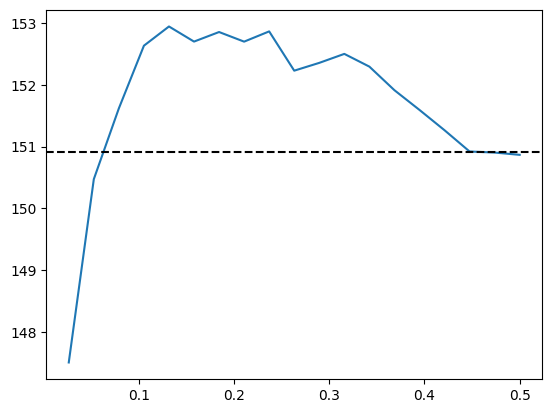

In [ ]:
plt.plot(wls, np.mean(rews_wl, axis=(1,2,3)))
plt.axhline(np.mean(rews_learn), color = 'k', ls = '--', label = 'learned')

In [ ]:
wls[np.argmax(np.mean(rews_wl, axis=(1,2,3)))]

np.float64(0.13157894736842105)

### Sweep over lambda1

In [ ]:
L, Nt, r = 50, 10, 0.5

idx_t = 0
tau = taus[idx_t]

episodes, time_ep = 10, 5000
max_counter =50

wl = 0.13157894736842105
lambda1s = np.linspace(0.2, 1.2*tau, 10)

rews_l = np.zeros((len(lambda1s), n_runs, num_agents, episodes))

for idx_w, lambda1 in enumerate(tqdm(lambda1s)):


    probs = np.array([1-wl, wl])
    lambdas = np.array([lambda1, 5*L])


    policy = np.array(get_policy_from_dist(n_max=max_counter,
                                        func = pdf_multimode,
                                        lambdas = lambdas,
                                        probs = probs
                                        ))

    h_mat = np.ones((num_agents, 2, 4*max_counter))
    h_mat[:, 0, :max_counter] = policy
    h_mat[:, 1, :max_counter] = 1-policy


    rews, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                    runs=n_runs,
                                    # Environment props
                                    Nt=Nt,
                                    L=L,
                                    r=r,
                                    tau=tau,
                                    num_agents=num_agents,
                                    agent_step=1,
                                    shared_depletion=False,
                                    visual_activated = False,
                                    # Agent props
                                    num_actions=2,
                                    state_space=state_space,
                                    initial_h_0 = True,
                                    h_0 = h_mat,
                                    no_learning = True
                                    )

    rews_l[idx_w] = rews

  0%|          | 0/20 [00:00<?, ?it/s]

<matplotlib.lines.Line2D>

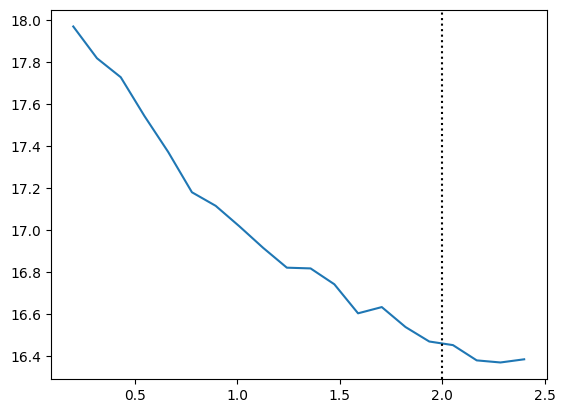

In [ ]:
plt.plot(lambda1s, np.mean(rews_l, axis=(1,2,3)))
# plt.axhline(np.mean(rews_learn), color = 'k', ls = '--', label = 'learned')
plt.axvline(tau, color = 'k', ls = ':', label = 'tau')

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient

agents = Foragers_efficient(num_agents, 2, state_space)

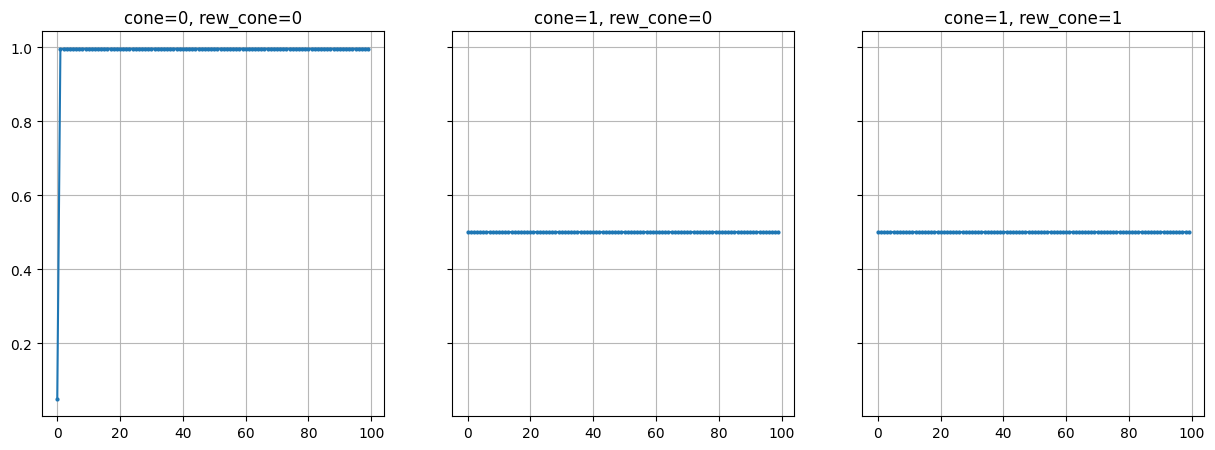

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(15, 5), sharex=True, sharey=True)
mats = h_mat.copy()
hflat = mats.reshape(-1, 2, mats.shape[-1])
p_keep = hflat[:, 0, :] / hflat.sum(1)


for cone_val in [0, 1]:
    for rew_val in [0, 1]:

        if cone_val == 0 and rew_val == 1:
            continue  # impossible state: can't see a rewarded agent if no agents are in the cone

        obs = np.hstack((np.arange(max_counter).reshape(-1,1), cone_val*np.ones((max_counter, 1))))
        obs = np.hstack((obs, rew_val*np.ones((max_counter, 1))))
        idxs = agents.percept_preprocess(obs)

        title = f"cone={cone_val}, rew_cone={rew_val}"
        axs[cone_val+rew_val].set_title(title)

        axs[cone_val+rew_val].plot(np.median(p_keep[:, idxs], axis=0), '-o', ms=2, label=fr'$N_t$ = {Nt}') 
        axs[cone_val+rew_val].grid(alpha = 0.9)

    

#### Test sweep on run_flight

In [ ]:
L, Nt, r = 50, 10, 0.5

idx_t = 0
tau = taus[idx_t]

wl = 0.13157894736842105
lambda1s = np.linspace(0.2, 4*tau, 10)

mfpt_sim = np.zeros(len(lambda1s))
sem_sim = np.zeros(len(lambda1s))
for idx_w, lambda1 in enumerate(tqdm(lambda1s)):

    m, s, f = run_flight(L, Nt, r, tau, [lambda1, 5*L], [1-wl, wl], W=1500, seed=5, h=0.2)
    mfpt_sim[idx_w] = m
    sem_sim[idx_w] = s

  0%|          | 0/10 [00:00<?, ?it/s]

<matplotlib.lines.Line2D>

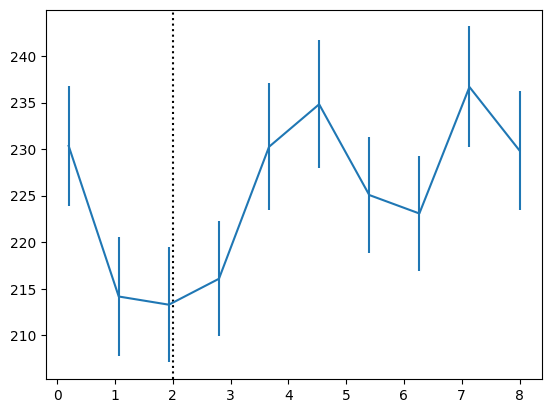

In [ ]:
# plt.plot(lambda1s, np.mean(rews_l, axis=(1,2,3)))
plt.errorbar(lambda1s, mfpt_sim, yerr=sem_sim, label = 'simulated MFPT')
plt.axvline(tau, color = 'k', ls = ':', label = 'tau')

<matplotlib.lines.Line2D>

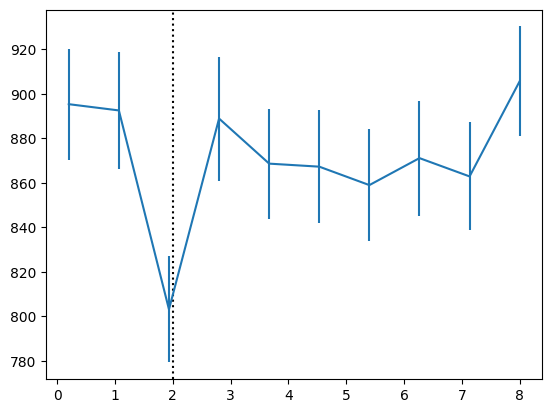

In [ ]:
# plt.plot(lambda1s, np.mean(rews_l, axis=(1,2,3)))
plt.errorbar(lambda1s, mfpt_sim, yerr=sem_sim, label = 'simulated MFPT')
plt.axvline(tau, color = 'k', ls = ':', label = 'tau')

In [ ]:
lambda1s

array([ 0.3       ,  0.42379092,  0.59866247,  0.84569239,  1.19465585,
        1.68761433,  2.38398541,  3.36770455,  4.757342  ,  6.72039443,
        9.49347373, 13.41082647, 18.9446215 , 26.76186174])

In [ ]:
wl

np.float64(0.09669634961196726)

b=17.8  MFP=1000  tau/b=0.11


  0%|          | 0/10 [00:00<?, ?it/s]

argmin per config: [ 2.2   0.67  1.48  3.28  4.89 16.18 35.92  0.99  3.28  1.48]


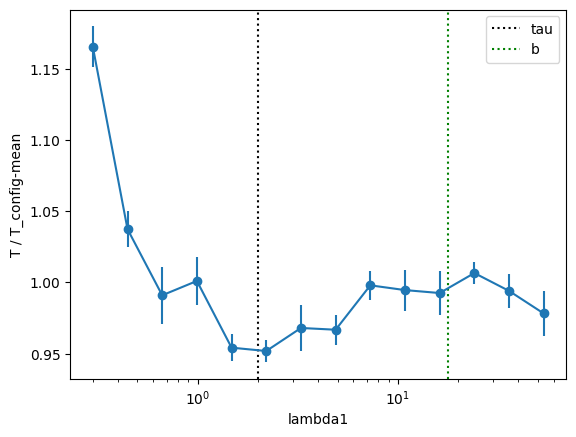

In [ ]:

L, Nt, r = 100, 10, 0.5
rho = Nt/L**2
b, MFP = 1/np.sqrt(np.pi*rho), 1/(2*r*rho)      # 17.8, 1000
tau = taus[idx_t]
d1 = 5*L
print(f"b={b:.1f}  MFP={MFP:.0f}  tau/b={tau/b:.2f}")

lambda1s = np.geomspace(0.3, 3*b, 14)
n_cfg, W = 10, 800

curves = np.zeros((n_cfg, len(lambda1s)))
for c in tqdm(range(n_cfg)):
    for i, lam in enumerate(lambda1s):
        wl = lam/(lam + d1)                      # equal path split, per lambda
        m, _, cens = run_flight(L, Nt, r, tau, [lam, d1], [1-wl, wl],
                                W=W, seed=1000+c, h=0.2)   # SAME seed across lambda
        curves[c, i] = m

shape = curves / curves.mean(axis=1, keepdims=True)   # kill per-config offset
mean, sem = shape.mean(0), shape.std(0, ddof=1)/np.sqrt(n_cfg)

plt.errorbar(lambda1s, mean, yerr=sem, fmt='o-')
plt.axvline(tau, color='k', ls=':', label='tau'); plt.axvline(b, color='g', ls=':', label='b')
plt.xscale('log'); plt.xlabel('lambda1'); plt.ylabel('T / T_config-mean'); plt.legend()
print("argmin per config:", lambda1s[shape.argmin(1)].round(2))

### Sweep over both

In [ ]:
max_counter =50
idx_t = 0

episodes, time_ep = 10, 5000

# L, Nt, r = 100, 20, 0.5
# tau = 5
# wls = np.linspace(0, .33, 3)
# lambda1s = np.linspace(0.1, 4, 10)

L, Nt, r = 150, 8, 0.5
tau = 2.0; seed = 7; h = 0.2
lambdas = np.linspace(0.5, 4, 10)
wls = np.linspace(0, 1, 10)



rews_l = np.zeros((len(wls), len(lambda1s), n_runs, num_agents, episodes))

for idx_l, lambda1 in enumerate(tqdm(lambda1s)):
    for idx_w, wl in enumerate(tqdm(wls)):


        probs = np.array([1-wl, wl])
        lambdas = np.array([lambda1, 5*L])


        policy = np.array(get_policy_from_dist(n_max=max_counter,
                                            func = pdf_multimode,
                                            lambdas = lambdas,
                                            probs = probs
                                            ))

        h_mat = np.ones((num_agents, 2, 4*max_counter))
        h_mat[:, 0, :max_counter] = policy
        h_mat[:, 1, :max_counter] = 1-policy


        rews, _ = run_collective(episodes = episodes, time_ep = time_ep, 
                                        runs=n_runs,
                                        # Environment props
                                        Nt=Nt,
                                        L=L,
                                        r=r,
                                        tau=tau,
                                        num_agents=num_agents,
                                        agent_step=1,
                                        shared_depletion=False,
                                        visual_activated = False,
                                        # Agent props
                                        num_actions=2,
                                        state_space=state_space,
                                        initial_h_0 = True,
                                        h_0 = h_mat,
                                        no_learning = True
                                        )

        rews_l[idx_w, idx_l] = rews

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

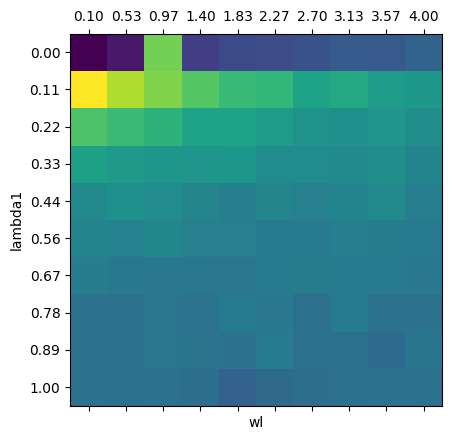

In [ ]:
plt.matshow(np.mean(rews_l, axis=(2,3,4)))
plt.xlabel('wl'); plt.ylabel('lambda1'); 
plt.yticks(ticks=np.arange(len(wls)), labels=[f"{w:.2f}" for w in wls])
plt.xticks(ticks=np.arange(len(lambda1s)), labels=[f"{l:.2f}" for l in lambda1s]);

In [ ]:
rews_l.shape

(10, 10, 35, 100, 10)

In [ ]:
(1/(np.mean(rews_l, axis=(2,3,4))/time_ep)).min()

np.float64(3014.954172696575)

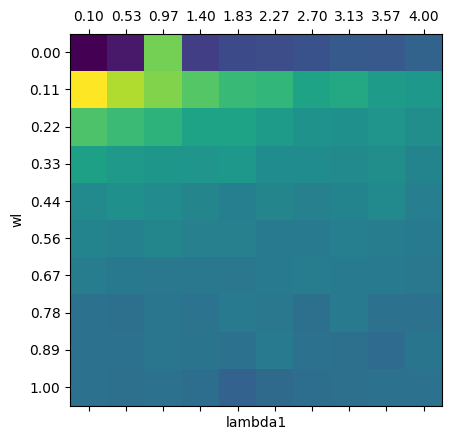

In [ ]:
plt.matshow(np.mean(rews_l, axis=(2,3,4)))
plt.ylabel('wl'); plt.xlabel('lambda1'); 
plt.yticks(ticks=np.arange(len(wls)), labels=[f"{w:.2f}" for w in wls])
plt.xticks(ticks=np.arange(len(lambda1s)), labels=[f"{l:.2f}" for l in lambda1s]);

# Reproducing Crossover with new functions

In [ ]:
import numpy as np

# environment
L, Nt, r = 150, 50, 0.5
THETA =  np.pi/4
rho = Nt / L**2
MFP = 1 / (2 * r * rho)
b   = 1 / np.sqrt(np.pi * rho)
D1  = 20 * MFP

taus = np.arange(2, 16)
VRs  = np.arange(2, 16)

num_runs = 4
W = 800


# --- blind depends on tau only (no VR): one row, reused across VRs ---
Tblind = np.zeros((len(taus), num_runs))
print('Starting blind')
for idxt, tau in enumerate(tqdm(taus)):
    for run in range(num_runs):
        m, s, c = run_flight(L, Nt, r, float(tau), [float(tau), D1], [0.0, 1.0],
                            W=W, seed=5*tau+3*run, h=0.2)          # pure ballistic
        Tblind[idxt, run] = m

# --- visual over the (tau, VR) grid ---
Tvis = np.full((len(taus), len(VRs), num_runs), np.nan)
for i, tau in enumerate(tqdm(taus)):
    for j, VR in enumerate(VRs):
        for run in range(num_runs):
            m, s, c = mfpt_visual(L=L, Nt=Nt, r=r, VR=float(VR), tau=float(tau),
                                theta=THETA, W=W, seed=300 + 7*tau + VR+5*run,
                                rule='dir')
            Tvis[i, j, run] = m

# --- winner table:  V if visual faster, B if blind faster ---
# print("winner  (V = visual faster, B = blind faster)")
# print("tau\\VR " + "".join(f"{VR:>4}" for VR in VRs))
# for i, tau in enumerate(taus):
#     cells = "".join(f"{'V' if Tvis[i,j] < Tblind[tau] else 'B':>4}" for j in range(len(VRs)))
#     print(f"{tau:5d} {cells}")

Starting blind


  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/14 [00:00<?, ?it/s]

In [ ]:
winner = np.where(Tvis.mean(-1) < Tblind.mean(-1)[:, np.newaxis])

In [ ]:
Tblind_rep = Tblind.mean(-1)[:,np.newaxis].repeat(14,1)

winner = (Tvis.mean(-1) < Tblind_rep).astype(int)

Text(0.5, 1.0, 'Nt=20, L=50, r=0.5, rho=0.008')

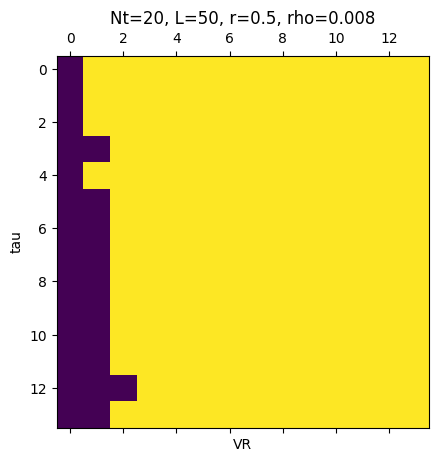

In [ ]:
plt.matshow(winner)
plt.xlabel('VR'); plt.ylabel('tau'); 
plt.title(f'Nt={Nt}, L={L}, r={r}, rho={rho:.3f}')

Text(0.5, 1.0, 'Nt=50, L=50, r=0.5, rho=0.020')

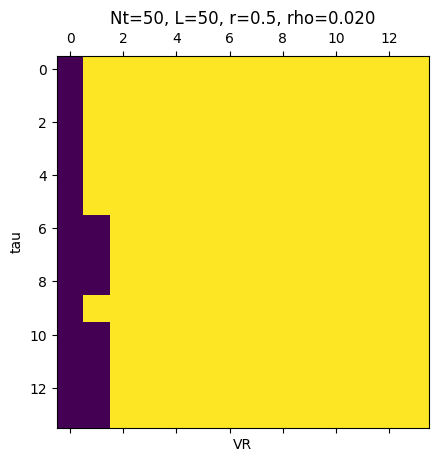

In [ ]:
plt.matshow(winner)
plt.xlabel('VR'); plt.ylabel('tau'); 
plt.title(f'Nt={Nt}, L={L}, r={r}, rho={rho:.3f}')

Text(0.5, 1.0, 'Nt=50, L=150, r=0.5, rho=0.002')

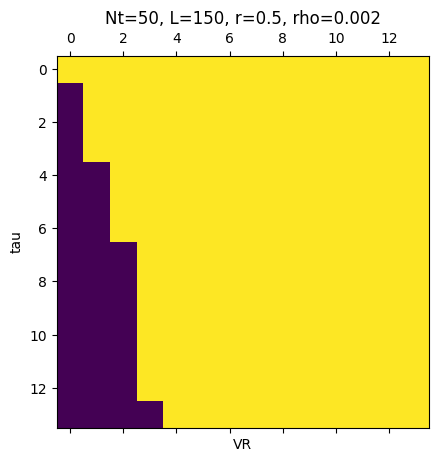

In [ ]:
plt.matshow(winner)
plt.xlabel('VR'); plt.ylabel('tau'); 
plt.title(f'Nt={Nt}, L={L}, r={r}, rho={rho:.3f}')

# Analytical phase transition

$$

  \mathrm{VR}_{\mathrm{eff}}^{*}
  = \tau \exp\!\left[-\frac{\pi}{4r}\left(1 - \frac{Br}{\tau}\right)\right]
  = \tau\, e^{-\pi/(4r)}\, e^{\,\pi B/(4\tau)} .
$$

In [ ]:
def VR_eff_star(tau, r=0.5, B=0.73):
    tau = np.asarray(tau, dtype=float)
    out = tau * np.exp(-(np.pi / (4.0 * r)) * (1.0 - B * r / tau))
    # the expression only makes sense while the exponent stays negative
    return np.where(tau > B * r, out, np.nan)

In [ ]:
taus = np.arange(2, 16)
VR_star = VR_eff_star(taus, r=0.5, B=0.73)

In [ ]:
np.round(VR_star)

array([1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 3., 3., 3., 3.])

(0.0, 10.0)

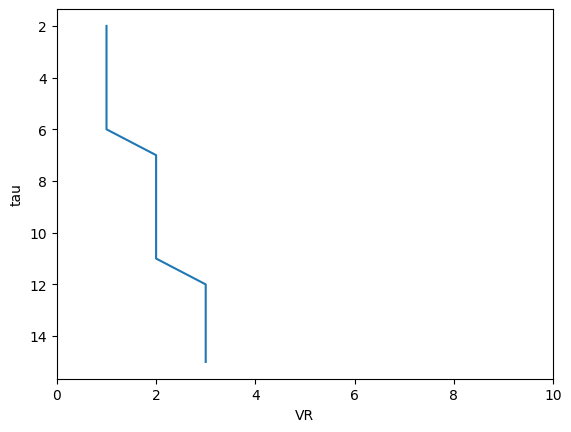

In [ ]:
plt.plot(np.round(VR_star), taus)
plt.xlabel('VR'); plt.ylabel('tau'); 
# put origin in top left corner
plt.gca().invert_yaxis()
plt.xlim(0, 10)

## Consider VR$_{eff}$

In [ ]:
from scipy.special import lambertw 

def VR_eff_star(tau, r=0.5, B=0.73):
    tau = np.asarray(tau, dtype=float)
    out = tau * np.exp(-(np.pi / (4.0 * r)) * (1.0 - B * r / tau))
    # the expression only makes sense while the exponent stays negative
    return np.where(tau > B * r, out, np.nan)

def _k(r, B = 0.73):
    return (np.pi / (4.0 * r)) * (1.0 - B * r)

def VR_l_star(tau, l, r=0.5, B=0.73):
    
    _denom = lambertw(l * np.exp(_k(r, B))/ tau)

    if np.imag(_denom).any() != 0:
        print('Lambert gave back imaginary!')
    else:
        denom = np.real(_denom)
    
    return l / denom


(16.0, 1.0)

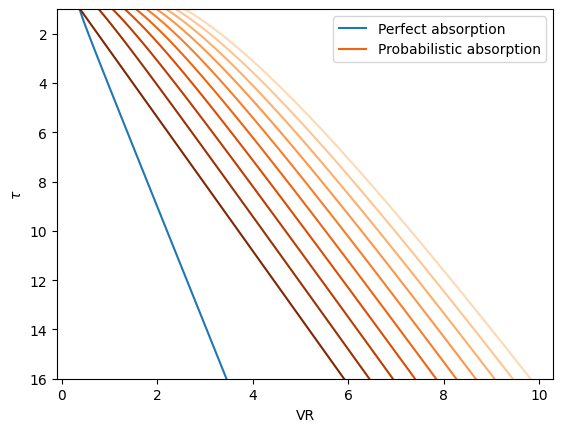

In [ ]:
taus = np.linspace(1, 16, 100)
VR_eff = VR_eff_star(taus, r=0.5, B=0.73)

plt.plot(VR_eff, taus, label = 'Perfect absorption')

ls = np.linspace(0.01,5,10)

colors = plt.cm.Oranges(np.linspace(1, 0.2, 10))
for idxl, l in enumerate(ls):
    VR_l = VR_l_star(taus, l = l, r=0.5, B=0.73)
    plt.plot(VR_l, taus, c = colors[idxl], label = 'Probabilistic absorption' if idxl == 4 else None)

plt.legend()
plt.xlabel('VR'); plt.ylabel(r'$\tau$'); 
# put origin in top left corner
plt.gca().invert_yaxis()
plt.ylim(taus.max(), taus.min())

(16.0, 1.0)

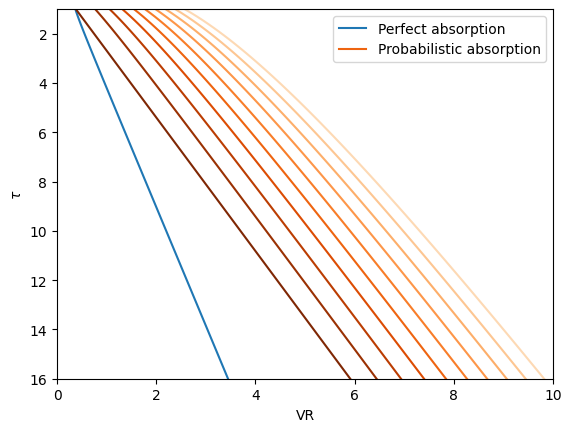

In [ ]:
taus = np.linspace(1, 16, 100)
VR_eff = VR_eff_star(taus, r=0.5, B=0.73)

plt.plot(VR_eff, taus, label = 'Perfect absorption')

ls = np.linspace(0.01,5,10)

colors = plt.cm.Oranges(np.linspace(1, 0.2, 10))
for idxl, l in enumerate(ls):
    VR_l = VR_l_star(taus, l = l, r=0.5, B=0.73)
    plt.plot(VR_l, taus, c = colors[idxl], label = 'Probabilistic absorption' if idxl == 4 else None)

plt.legend()
plt.xlabel('VR'); plt.ylabel(r'$\tau$'); 
# put origin in top left corner
plt.gca().invert_yaxis()
plt.xlim(0, 10); plt.ylim(taus.max(), taus.min())

# MFPT as function of $p_c$

In [ ]:
import numpy as np
from scipy.special import iv


def reactive_length(p_c, VR, D=0.25, d=1.0):
    """Reactive length from the interior killing problem.

        ell = sqrt(D/k) * I0(q)/I1(q),   k = p_c/d,   q = VR*sqrt(k/D)

    Valid while the absorption length delta = sqrt(D/k) exceeds the step d,
    i.e. p_c << 1/4. Returns inf at p_c = 0 (transparent trap).
    """
    p_c = np.asarray(p_c, dtype=float)
    k = p_c / d
    with np.errstate(divide='ignore', invalid='ignore'):
        delta = np.sqrt(D / k)
        q = VR / delta
        ell = delta * iv(0, q) / iv(1, q)
    return np.where(p_c > 0, ell, np.inf)


def mfpt_partial_abs(tau, VR, p_c, rho=None, L=None, Nt=None, r=None,
         D=0.25, d=1.0, kappa=0.52, exact=False):
    """MFPT of the partially absorbing searcher.

        T = (VR^2 - tau^2)/(4D) + (b^2/2D)*ln(tau/VR_eff) + ell*(b^2-VR^2)/(2D*VR)

    or, with exact=False (default), the dilute leading form

        T = A * ln(tau/VR_eff),   A = 2/(pi*rho),   VR_eff = VR*exp(-ell/VR)

    Density: give rho directly, or L and Nt.
    If r is given, VR_eff is floored at kappa*r (the contact channel).
    """
    if rho is None:
        if L is None or Nt is None:
            raise ValueError("give rho, or both L and Nt")
        rho = Nt / L**2
    b = 1.0 / np.sqrt(np.pi * rho)
    A = 2.0 / (np.pi * rho)                      # = b^2/(2D) with D = 1/4

    ell = reactive_length(p_c, VR, D=D, d=d)
    VR_eff = VR * np.exp(-ell / VR)
    if r is not None:
        VR_eff = np.maximum(VR_eff, kappa * r)

    if not exact:
        return A * np.log(tau / VR_eff)
    return ((VR**2 - tau**2) / (4 * D)
            + (b**2 / (2 * D)) * np.log(tau / VR)
            + ell * (b**2 - VR**2) / (2 * D * VR))


def validity(tau, VR, p_c, rho=None, L=None, Nt=None, D=0.25, d=1.0):
    """Conditions the derivation assumes. Returns a list of violations."""
    if rho is None:
        rho = Nt / L**2
    b = 1.0 / np.sqrt(np.pi * rho)
    bad = []
    if p_c > 0.25:
        bad.append(f"p_c={p_c:.3f} > 1/4: absorption length < step, "
                   "diffusive interior invalid")
    if VR < 3 * d:
        bad.append(f"VR={VR} < 3d: circle under-resolved by the step")
    if tau > 0.6 * b:
        bad.append(f"tau={tau} > 0.6b={0.6*b:.1f}: outside single-cell picture")
    if VR > 0.2 * b:
        bad.append(f"VR={VR} > 0.2b={0.2*b:.1f}: not dilute")
    if tau <= VR:
        bad.append("tau <= VR: starts inside the detection disk")
    return bad



L, Nt, r = 3000, 90, 0.5
VRs = np.linspace(3, 6, 10)
p_c = 1/9
tau = 8
Ts = []
valid = []
for VR in VRs:
    # p_c = np.arcsin(min(r / VR, 1)) / np.pi          # wide cone
    print(validity(tau, VR, p_c, L=L, Nt=Nt))
    if len(validity(tau, VR, p_c, L=L, Nt=Nt)) == 0:
        Ts.append(mfpt_partial_abs(tau=tau, VR=VR, p_c=p_c, L=L, Nt=Nt, r=r))
    else:
        Ts.append(np.nan)
#     print(f"VR={VR:2d}  p_c={p_c:.4f}  "
#             f"ell={float(reactive_length(p_c, VR)):5.2f}  T={T:8.1f}")
# print("\nvalidity at VR=3:", validity(8.0, 3.0, 0.053, L=L, Nt=Nt) or "ok")

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]


In [ ]:
validity(tau, VR, p_c, L=L, Nt=Nt)

['VR=12.0 > 0.2b=3.6: not dilute',
 'tau <= VR: starts inside the detection disk']

[<matplotlib.lines.Line2D>]

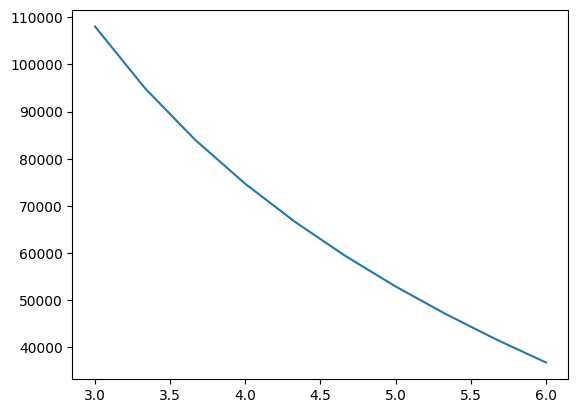

In [ ]:
plt.plot(VRs, Ts)